# OCR GAN Notebook for Kaggle

This notebook is written for Kaggle GPU, not TPU. It uses a pix2pix-style conditional GAN to generate content-preserving document degradations and then evaluates OCR robustness with free local OCR models by default.

OCR attack loss is not used as a differentiable training objective for black-box APIs. Instead, the notebook trains the GAN with adversarial and reconstruction losses, then evaluates the results with local OCR engines and an optional free OCR.space API call.

Primary OCR options in this notebook:
- TrOCR
- EasyOCR
- pytesseract, if the Tesseract binary is available in the environment
- Optional OCR.space free-tier API through an environment variable

SynthText labels are loaded directly from `gt.mat` when available, so the notebook can compute real OCR accuracy metrics instead of only qualitative outputs.

Kaggle is the better default for this project because it gives you a normal GPU workflow for GANs. TPU is not a good fit for this training setup.

In [ ]:
# pyright: reportMissingImports=false

import os
import sys
import json
import math
import random
import re
import subprocess
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageFilter, ImageOps, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid


def install_if_missing(package_name: str) -> None:
    try:
        __import__(package_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


for package_name in [
    "python-dotenv",
    "easyocr",
    "transformers",
    "sentencepiece",
    "scipy",
    "opencv-python-headless",
    "requests",
    "tqdm",
]:
    try:
        __import__(package_name.replace("-", "_"))
    except Exception:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package_name], check=False)


try:
    from dotenv import load_dotenv
except Exception:
    load_dotenv = None

try:
    import cv2
except Exception:
    cv2 = None

try:
    import requests
except Exception:
    requests = None

try:
    import easyocr
except Exception:
    easyocr = None

try:
    import pytesseract
except Exception:
    pytesseract = None

try:
    from scipy.io import loadmat
except Exception:
    loadmat = None

try:
    from transformers import TrOCRProcessor, VisionEncoderDecoderModel
except Exception:
    TrOCRProcessor = None
    VisionEncoderDecoderModel = None

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable, **_kwargs):
        return iterable if not _kwargs else iterable


if load_dotenv is not None:
    load_dotenv(".env")


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Torch version: {torch.__version__}")


RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.benchmark = True


@dataclass
class ProjectConfig:
    kaggle_input_roots: List[str] = field(default_factory=lambda: ["/kaggle/input/synthtext/SynthText"])
    work_root: Path = Path("/kaggle/working")
    output_root: Path = Path("/kaggle/working/ocr_gan_outputs")
    checkpoints_root: Path = Path("/kaggle/working/ocr_gan_checkpoints")
    image_size: int = 256
    batch_size: int = 10
    num_workers: int = 2
    learning_rate: float = 1.2e-4
    min_learning_rate_ratio: float = 0.15
    beta1: float = 0.5
    lambda_l1: float = 80.0
    lambda_identity: float = 6.0
    lambda_edge: float = 6.5
    lambda_perceptual: float = 1.0
    lambda_text_focus: float = 32.0
    lambda_structure: float = 5.0
    lambda_tv: float = 0.04
    generator_residual_scale: float = 0.28
    epochs: int = 20
    max_train_samples: Optional[int] = 10000
    max_eval_samples: Optional[int] = 320
    eval_split: float = 0.12
    min_text_length: int = 2
    max_text_length: int = 28
    min_crop_width: int = 24
    min_crop_height: int = 16
    gradcam_samples: int = 3
    ocr_proxy_eval_samples: int = 48
    ocr_proxy_eval_frequency: int = 2
    trocr_model_name: str = "microsoft/trocr-base-printed"
    ocrspace_api_key: str = ""


config = ProjectConfig()
config.output_root.mkdir(parents=True, exist_ok=True)
config.checkpoints_root.mkdir(parents=True, exist_ok=True)


print(json.dumps({
    "image_size": config.image_size,
    "batch_size": config.batch_size,
    "epochs": config.epochs,
    "max_train_samples": config.max_train_samples,
    "max_eval_samples": config.max_eval_samples,
    "eval_split": config.eval_split,
    "trocr_available": TrOCRProcessor is not None and VisionEncoderDecoderModel is not None,
    "ocrspace_api_key_present": bool(config.ocrspace_api_key),
}, indent=2))

Using device: cuda
Torch version: 2.10.0+cu128
{
  "image_size": 256,
  "batch_size": 10,
  "epochs": 20,
  "max_train_samples": 10000,
  "max_eval_samples": 320,
  "eval_split": 0.12,
  "trocr_available": true,
  "ocrspace_api_key_present": true
}


## Kaggle Notebook Setup and Dataset Loading

Use Kaggle GPU for this project. Attach your datasets in Kaggle and point the notebook at the `/kaggle/input/...` directories.

If you already have a clean text-image dataset with transcripts, the notebook can build a manifest from a CSV or scan a folder recursively. If you only have image folders, the notebook can still run, but OCR evaluation will be text-less until you supply labels.

In [3]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}


def list_kaggle_roots() -> List[Path]:
    root = Path("/kaggle/input")
    if not root.exists():
        return []
    return [path for path in root.iterdir() if path.is_dir()]


print("Available Kaggle input roots:")
for root in list_kaggle_roots():
    print(" -", root)


@dataclass
class SampleRecord:
    image_path: Path
    text: str = ""


def find_csv_manifest(root: Path) -> Optional[Path]:
    for candidate in root.rglob("*.csv"):
        lower_name = candidate.name.lower()
        if any(token in lower_name for token in ["manifest", "labels", "annotation", "annotations", "train", "gt"]):
            return candidate
    csv_files = list(root.rglob("*.csv"))
    return csv_files[0] if csv_files else None


def find_synthtext_ground_truth(root: Path) -> Optional[Path]:
    for candidate in [root / "gt.mat", root / "SynthText" / "gt.mat"]:
        if candidate.exists():
            return candidate
    matches = list(root.rglob("gt.mat"))
    return matches[0] if matches else None


def matlab_to_string(value) -> str:
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="ignore")
    if isinstance(value, str):
        return value
    if isinstance(value, np.ndarray):
        if value.size == 0:
            return ""
        if value.dtype.kind in {"U", "S"}:
            return " ".join(str(item) for item in value.flatten().tolist())
        if value.size == 1:
            return matlab_to_string(value.item())
        return " ".join(part for part in (matlab_to_string(item) for item in value.flatten()) if part)
    return str(value)


def normalize_synthtext_transcript(value) -> str:
    raw_text = matlab_to_string(value)
    raw_text = raw_text.replace("\r", "\n")
    lines = [line.strip() for line in raw_text.split("\n") if line.strip()]
    return " ".join(lines)


def tokenize_synthtext_transcript(value) -> List[str]:
    transcript = normalize_synthtext_transcript(value)
    tokens = [token.strip() for token in re.split(r"\s+", transcript) if token.strip()]
    return tokens


def extract_synthtext_word_boxes(value) -> List[Tuple[int, int, int, int]]:
    if value is None:
        return []

    try:
        points = np.asarray(value, dtype=np.float32)
    except Exception:
        return []

    if points.size == 0:
        return []

    if points.ndim == 2:
        if points.shape == (2, 4):
            points = points.reshape(2, 4, 1)
        else:
            try:
                points = points.reshape(2, 4, -1)
            except Exception:
                return []
    elif points.ndim != 3:
        try:
            points = points.reshape(2, 4, -1)
        except Exception:
            return []

    if points.shape[0] == 4 and points.shape[1] == 2:
        points = points.transpose(1, 0, 2)

    if points.shape[0] != 2 or points.shape[1] != 4:
        return []

    crop_boxes: List[Tuple[int, int, int, int]] = []
    for index in range(points.shape[2]):
        polygon = points[:, :, index]
        x_coordinates = polygon[0]
        y_coordinates = polygon[1]
        if x_coordinates.size == 0 or y_coordinates.size == 0:
            continue
        left = int(np.floor(np.nanmin(x_coordinates)))
        top = int(np.floor(np.nanmin(y_coordinates)))
        right = int(np.ceil(np.nanmax(x_coordinates)))
        bottom = int(np.ceil(np.nanmax(y_coordinates)))
        if right <= left or bottom <= top:
            continue
        crop_boxes.append((left, top, right, bottom))
    return crop_boxes


def expand_crop_box(
    crop_box: Tuple[int, int, int, int],
    image_width: int,
    image_height: int,
    padding_ratio: float = 0.14,
    min_padding: int = 6,
) -> Tuple[int, int, int, int]:
    left, top, right, bottom = crop_box
    padding_x = max(min_padding, int((right - left) * padding_ratio))
    padding_y = max(min_padding, int((bottom - top) * padding_ratio))
    expanded_left = max(0, left - padding_x)
    expanded_top = max(0, top - padding_y)
    expanded_right = min(image_width, right + padding_x)
    expanded_bottom = min(image_height, bottom + padding_y)
    return (expanded_left, expanded_top, expanded_right, expanded_bottom)


def build_synthtext_dataframe(root: Path, max_samples: Optional[int] = None) -> Optional[pd.DataFrame]:
    gt_path = find_synthtext_ground_truth(root)
    if gt_path is None or loadmat is None:
        return None

    try:
        gt_data = loadmat(gt_path)
    except Exception as error:
        print(f"Failed to read SynthText labels from {gt_path}: {error}")
        return None

    imnames = gt_data.get("imnames")
    txt_values = gt_data.get("txt")
    word_boxes = gt_data.get("wordBB")
    if imnames is None or txt_values is None:
        return None

    image_entries = imnames.ravel()
    text_entries = txt_values.ravel()
    word_box_entries = word_boxes.ravel() if word_boxes is not None else []
    row_count = min(len(image_entries), len(text_entries))
    rows = []
    mismatched_samples = 0

    for index in range(row_count):
        relative_path = matlab_to_string(image_entries[index]).strip()
        if not relative_path:
            continue

        tokens = tokenize_synthtext_transcript(text_entries[index])
        if not tokens:
            continue

        image_path = (gt_path.parent / relative_path).resolve()
        crop_boxes = extract_synthtext_word_boxes(word_box_entries[index]) if index < len(word_box_entries) else []

        if crop_boxes:
            usable_count = min(len(tokens), len(crop_boxes))
            if usable_count != len(tokens) or usable_count != len(crop_boxes):
                mismatched_samples += 1

            for word_index in range(usable_count):
                token = tokens[word_index].strip()
                if len(token) < config.min_text_length or len(token) > config.max_text_length:
                    continue

                crop_left, crop_top, crop_right, crop_bottom = crop_boxes[word_index]
                crop_width = crop_right - crop_left
                crop_height = crop_bottom - crop_top
                if crop_width < config.min_crop_width or crop_height < config.min_crop_height:
                    continue

                rows.append({
                    "image_path": str(image_path),
                    "text": token,
                    "crop_left": crop_left,
                    "crop_top": crop_top,
                    "crop_right": crop_right,
                    "crop_bottom": crop_bottom,
                    "source": "synthtext_word",
                    "sample_index": index,
                    "word_index": word_index,
                })
                if max_samples is not None and len(rows) >= max_samples:
                    break
        else:
            transcript = normalize_synthtext_transcript(text_entries[index])
            if len(transcript) < config.min_text_length or len(transcript) > max(config.max_text_length * 3, 64):
                continue
            rows.append({
                "image_path": str(image_path),
                "text": transcript,
                "crop_left": np.nan,
                "crop_top": np.nan,
                "crop_right": np.nan,
                "crop_bottom": np.nan,
                "source": "synthtext_full",
                "sample_index": index,
                "word_index": -1,
            })

        if max_samples is not None and len(rows) >= max_samples:
            break

    if not rows:
        return None

    dataframe = pd.DataFrame(rows)
    print(f"Loaded SynthText labels from: {gt_path}")
    if mismatched_samples:
        print(f"Word/token count mismatches handled on {mismatched_samples} SynthText images")
    return dataframe


def read_manifest(csv_path: Path) -> pd.DataFrame:
    dataframe = pd.read_csv(csv_path)
    columns = {column.lower(): column for column in dataframe.columns}
    image_column = None
    text_column = None
    for candidate in ["image_path", "path", "file", "filename", "img", "image"]:
        if candidate in columns:
            image_column = columns[candidate]
            break
    for candidate in ["text", "label", "transcript", "gt_text", "ground_truth"]:
        if candidate in columns:
            text_column = columns[candidate]
            break
    if image_column is None:
        raise ValueError(f"Could not find an image path column in {csv_path}")
    if text_column is None:
        dataframe["text"] = ""
        text_column = "text"

    selected_columns = [image_column, text_column]
    optional_crop_columns = []
    for column_name in ["crop_left", "crop_top", "crop_right", "crop_bottom"]:
        if column_name in dataframe.columns:
            optional_crop_columns.append(column_name)
    selected_columns.extend(optional_crop_columns)

    dataframe = dataframe[selected_columns].copy()
    rename_map = {image_column: "image_path", text_column: "text"}
    dataframe = dataframe.rename(columns=rename_map)
    dataframe["image_path"] = dataframe["image_path"].astype(str)
    dataframe["text"] = dataframe["text"].astype(str)
    dataframe["source"] = "manifest"
    return dataframe


def discover_image_rows(root: Path, max_samples: Optional[int] = None) -> pd.DataFrame:
    synthtext_dataframe = build_synthtext_dataframe(root, max_samples=max_samples)
    if synthtext_dataframe is not None:
        return synthtext_dataframe

    csv_manifest = find_csv_manifest(root)
    if csv_manifest is not None:
        print(f"Using manifest: {csv_manifest}")
        dataframe = read_manifest(csv_manifest)
        dataframe["image_path"] = dataframe["image_path"].apply(
            lambda value: str((csv_manifest.parent / value).resolve()) if not os.path.isabs(value) else value
        )
        if max_samples is not None:
            dataframe = dataframe.head(max_samples)
        return dataframe

    image_paths = [path for path in root.rglob("*") if path.suffix.lower() in IMAGE_EXTENSIONS]
    rows = [{"image_path": str(path), "text": "", "source": "images_only"} for path in image_paths]
    dataframe = pd.DataFrame(rows)
    if max_samples is not None:
        dataframe = dataframe.head(max_samples)
    return dataframe


configured_roots = [Path(path) for path in config.kaggle_input_roots if Path(path).exists()]
candidate_roots = configured_roots if configured_roots else list_kaggle_roots()

if candidate_roots:
    dataset_parts = []
    for root in candidate_roots:
        dataframe = discover_image_rows(root, config.max_train_samples)
        if not dataframe.empty:
            dataset_parts.append(dataframe)
    dataset_dataframe = pd.concat(dataset_parts, ignore_index=True) if dataset_parts else pd.DataFrame(columns=["image_path", "text"])
else:
    dataset_dataframe = pd.DataFrame(columns=["image_path", "text"])

if not dataset_dataframe.empty:
    dataset_dataframe = dataset_dataframe.copy()
    dataset_dataframe["image_path"] = dataset_dataframe["image_path"].astype(str)
    dataset_dataframe = dataset_dataframe[dataset_dataframe["image_path"].apply(lambda value: Path(value).exists())].reset_index(drop=True)
    dataset_dataframe["text"] = dataset_dataframe["text"].fillna("").astype(str)
    dataset_dataframe["text"] = dataset_dataframe["text"].apply(lambda value: " ".join(value.split()))
    dataset_dataframe["text_length"] = dataset_dataframe["text"].str.len()
    dataset_dataframe = dataset_dataframe[
        dataset_dataframe["text"].eq("")
        | dataset_dataframe["text_length"].between(config.min_text_length, max(config.max_text_length * 3, 64))
    ].reset_index(drop=True)
    dataset_dataframe = dataset_dataframe.drop_duplicates().sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Loaded {len(dataset_dataframe)} candidate samples")
print(f"Rows with non-empty text labels: {int(dataset_dataframe['text'].astype(str).str.strip().ne('').sum()) if not dataset_dataframe.empty else 0}")
if not dataset_dataframe.empty and "source" in dataset_dataframe.columns:
    print(dataset_dataframe["source"].value_counts().to_dict())
    print({
        "median_text_length": float(dataset_dataframe[dataset_dataframe["text"].ne("")]["text_length"].median()) if dataset_dataframe[dataset_dataframe["text"].ne("")].shape[0] else 0.0,
        "median_crop_width": float((dataset_dataframe["crop_right"] - dataset_dataframe["crop_left"]).dropna().median()) if {"crop_left", "crop_right"}.issubset(dataset_dataframe.columns) else 0.0,
        "median_crop_height": float((dataset_dataframe["crop_bottom"] - dataset_dataframe["crop_top"]).dropna().median()) if {"crop_top", "crop_bottom"}.issubset(dataset_dataframe.columns) else 0.0,
    })
display(dataset_dataframe.head())


if len(dataset_dataframe) == 0:
    print("No attached dataset found yet. Upload SynthText/MJSynth or your own OCR dataset to Kaggle and rerun this cell.")

Available Kaggle input roots:
 - /kaggle/input/datasets
Loaded SynthText labels from: /kaggle/input/datasets/wassefy/synthtext/SynthText/gt.mat
Loaded 10000 candidate samples
Rows with non-empty text labels: 10000
{'synthtext_word': 10000}
{'median_text_length': 4.0, 'median_crop_width': 63.0, 'median_crop_height': 32.0}


,image_path,text,crop_left,crop_top,crop_right,crop_bottom,source,sample_index,word_index,text_length
0,/kaggle/input/datasets/wassefy/synthtext/Synth...,Doug,12,520,105,569,synthtext_word,584,5,4
1,/kaggle/input/datasets/wassefy/synthtext/Synth...,expierence!),106,462,272,521,synthtext_word,475,8,12
2,/kaggle/input/datasets/wassefy/synthtext/Synth...,one,493,43,547,69,synthtext_word,188,7,3
3,/kaggle/input/datasets/wassefy/synthtext/Synth...,Lines:,13,82,72,98,synthtext_word,478,9,6
4,/kaggle/input/datasets/wassefy/synthtext/Synth...,From:,51,483,125,517,synthtext_word,467,12,5


## Preprocess Images for OCR and Training

The GAN training path uses synthetic document degradations created on the fly from clean inputs.

The OCR evaluation path uses preprocessing helpers such as grayscale conversion, denoising, thresholding, and resizing before sending images to the OCR engines.

In [4]:
def pil_to_rgb_array(image: Image.Image) -> np.ndarray:
    return np.array(image.convert("RGB"))


def estimate_background_color(image: Image.Image) -> Tuple[int, int, int]:
    image_array = np.asarray(image.convert("RGB"), dtype=np.uint8)
    if image_array.size == 0:
        return (255, 255, 255)

    border_pixels = np.concatenate(
        [
            image_array[0, :, :],
            image_array[-1, :, :],
            image_array[:, 0, :],
            image_array[:, -1, :],
        ],
        axis=0,
    )
    median_color = np.median(border_pixels, axis=0).astype(np.uint8)
    return tuple(int(channel) for channel in median_color.tolist())


def resize_with_padding(
    image: Image.Image,
    size: int = 256,
    background_color: Optional[Tuple[int, int, int]] = None,
) -> Image.Image:
    working_image = image.convert("RGB")
    width, height = working_image.size
    if width <= 0 or height <= 0:
        return Image.new("RGB", (size, size), background_color or (255, 255, 255))

    if background_color is None:
        background_color = estimate_background_color(working_image)

    scale = min(size / width, size / height)
    scaled_width = max(1, int(round(width * scale)))
    scaled_height = max(1, int(round(height * scale)))
    resized = working_image.resize((scaled_width, scaled_height), Image.Resampling.LANCZOS)

    canvas = Image.new("RGB", (size, size), background_color)
    offset_x = (size - scaled_width) // 2
    offset_y = (size - scaled_height) // 2
    canvas.paste(resized, (offset_x, offset_y))
    return canvas


def apply_jpeg_artifacts(image: Image.Image, quality: int) -> Image.Image:
    import io

    buffer = io.BytesIO()
    image.save(buffer, format="JPEG", quality=quality, optimize=False)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")


def add_document_degradation(
    image: Image.Image,
    rng: Optional[random.Random] = None,
    np_rng: Optional[np.random.Generator] = None,
) -> Image.Image:
    rng = rng or random
    np_rng = np_rng or np.random.default_rng()
    working_image = image.convert("RGB")
    width, height = working_image.size

    if rng.random() < 0.8:
        brightness = ImageEnhance.Brightness(working_image)
        working_image = brightness.enhance(rng.uniform(0.9, 1.08))

    if rng.random() < 0.8:
        contrast = ImageEnhance.Contrast(working_image)
        working_image = contrast.enhance(rng.uniform(0.75, 1.25))

    if rng.random() < 0.4:
        sharpness = ImageEnhance.Sharpness(working_image)
        working_image = sharpness.enhance(rng.uniform(0.75, 1.35))

    if rng.random() < 0.4:
        working_image = working_image.filter(ImageFilter.GaussianBlur(radius=rng.uniform(0.15, 0.9)))

    overlay = Image.new("RGBA", (width, height), (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    if rng.random() < 0.7:
        top_alpha = rng.randint(6, 30)
        bottom_alpha = rng.randint(0, 20)
        for y_coordinate in range(height):
            alpha = int(top_alpha + (bottom_alpha - top_alpha) * (y_coordinate / max(height - 1, 1)))
            draw.line((0, y_coordinate, width, y_coordinate), fill=(0, 0, 0, alpha))

    if rng.random() < 0.45:
        shadow_width = rng.randint(max(8, width // 8), max(12, width // 3))
        shadow_x0 = rng.randint(0, max(0, width - shadow_width))
        draw.rectangle(
            (shadow_x0, 0, shadow_x0 + shadow_width, height),
            fill=(0, 0, 0, rng.randint(10, 35)),
        )

    if rng.random() < 0.3:
        fold_x = rng.randint(0, max(width - 1, 0))
        draw.line(
            (fold_x, 0, fold_x + rng.randint(-8, 8), height),
            fill=(255, 255, 255, rng.randint(12, 40)),
            width=rng.randint(1, 2),
        )

    blended = Image.alpha_composite(working_image.convert("RGBA"), overlay).convert("RGB")

    if rng.random() < 0.45:
        noisy = np.asarray(blended).astype(np.float32)
        noise = np_rng.normal(0.0, rng.uniform(1.0, 8.0), noisy.shape).astype(np.float32)
        noisy = np.clip(noisy + noise, 0, 255).astype(np.uint8)
        blended = Image.fromarray(noisy)

    if rng.random() < 0.35:
        blended = apply_jpeg_artifacts(blended, quality=rng.randint(35, 70))

    return blended


preprocess_for_ocr = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Lambda(lambda image: resize_with_padding(image, config.image_size)),
    transforms.Grayscale(num_output_channels=1),
])


train_image_transform = transforms.Compose([
    transforms.Lambda(lambda image: resize_with_padding(image, config.image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


def tensor_to_pil(image_tensor: torch.Tensor) -> Image.Image:
    if image_tensor.dim() == 4:
        image_tensor = image_tensor[0]
    image_tensor = image_tensor.detach().cpu().clamp(-1, 1)
    image_tensor = (image_tensor + 1.0) / 2.0
    image_array = (image_tensor.permute(1, 2, 0).numpy() * 255.0).astype(np.uint8)
    return Image.fromarray(image_array)


def normalize_for_display(image_tensor: torch.Tensor) -> torch.Tensor:
    return image_tensor.clamp(-1, 1)


print("Preprocessing helpers are ready.")

Preprocessing helpers are ready.


## Run OCR with Free Local Engines and Optional Free API

The notebook evaluates OCR with free local engines first. That keeps the workflow runnable even if you do not want to use any online API.

The default OCR stack is TrOCR, EasyOCR, and Tesseract. OCR.space remains optional and is used only when you provide a key in `.env`.

In [5]:
class TrOCRRunner:
    def __init__(self, model_name: str):
        self.processor = None
        self.model = None
        self.init_error = None

        if TrOCRProcessor is None or VisionEncoderDecoderModel is None:
            self.init_error = RuntimeError("transformers TrOCR is not installed")
            return

        try:
            self.processor = TrOCRProcessor.from_pretrained(model_name)
            self.model = VisionEncoderDecoderModel.from_pretrained(model_name).to(DEVICE)
            self._sync_model_special_tokens()
            self.model.eval()
        except Exception as error:
            self.init_error = error
            print(f"TrOCR initialization failed: {error}")

    def _sync_model_special_tokens(self) -> None:
        if self.processor is None or self.model is None:
            return

        tokenizer = getattr(self.processor, "tokenizer", None)
        if tokenizer is None:
            return

        pad_token_id = getattr(self.model.config, "pad_token_id", None)
        if pad_token_id is None:
            pad_token_id = getattr(tokenizer, "pad_token_id", None)
        if pad_token_id is None:
            pad_token_id = getattr(tokenizer, "eos_token_id", None)

        decoder_start_token_id = getattr(self.model.config, "decoder_start_token_id", None)
        if decoder_start_token_id is None:
            decoder_start_token_id = getattr(tokenizer, "cls_token_id", None)
        if decoder_start_token_id is None:
            decoder_start_token_id = getattr(tokenizer, "bos_token_id", None)
        if decoder_start_token_id is None:
            decoder_start_token_id = getattr(tokenizer, "eos_token_id", None)

        eos_token_id = getattr(self.model.config, "eos_token_id", None)
        if eos_token_id is None:
            eos_token_id = getattr(tokenizer, "sep_token_id", None)
        if eos_token_id is None:
            eos_token_id = getattr(tokenizer, "eos_token_id", None)

        config_candidates = [
            self.model.config,
            getattr(self.model.config, "decoder", None),
            getattr(self.model, "generation_config", None),
        ]
        for config_object in config_candidates:
            if config_object is None:
                continue
            if pad_token_id is not None:
                setattr(config_object, "pad_token_id", int(pad_token_id))
            if decoder_start_token_id is not None:
                setattr(config_object, "decoder_start_token_id", int(decoder_start_token_id))
            if eos_token_id is not None:
                setattr(config_object, "eos_token_id", int(eos_token_id))

    def supports_supervised_loss(self) -> bool:
        if self.model is None:
            return False
        return (
            getattr(self.model.config, "pad_token_id", None) is not None
            and getattr(self.model.config, "decoder_start_token_id", None) is not None
        )

    @torch.no_grad()
    def __call__(self, image: Image.Image) -> str:
        if self.processor is None or self.model is None:
            return ""
        self._sync_model_special_tokens()
        pixel_values = self.processor(images=image.convert("RGB"), return_tensors="pt").pixel_values.to(DEVICE)
        generated_ids = self.model.generate(pixel_values, max_new_tokens=32)
        return self.processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()


class EasyOCRRunner:
    def __init__(self, languages: Sequence[str] = ("en",)):
        self.reader = None
        if easyocr is not None:
            self.reader = easyocr.Reader(list(languages), gpu=torch.cuda.is_available())

    def __call__(self, image: Image.Image) -> str:
        if self.reader is None:
            return ""
        image_array = np.array(image.convert("RGB"))
        result = self.reader.readtext(image_array, detail=1, paragraph=False)
        if not result:
            return ""
        result = sorted(
            result,
            key=lambda item: (
                min(point[1] for point in item[0]),
                min(point[0] for point in item[0]),
            ),
        )
        text_chunks = [item[1].strip() for item in result if str(item[1]).strip()]
        return " ".join(text_chunks).strip()


class TesseractRunner:
    def __call__(self, image: Image.Image) -> str:
        if pytesseract is None:
            return ""
        configs = ["--oem 3 --psm 7", "--oem 3 --psm 8", "--oem 3 --psm 6"]
        for config_string in configs:
            try:
                text = pytesseract.image_to_string(image, config=config_string).strip()
            except Exception:
                text = ""
            if text:
                return text
        return ""


class OCRSpaceRunner:
    def __init__(self, api_key: str = ""):
        self.api_key = api_key.strip()

    def __call__(self, image: Image.Image) -> str:
        if not self.api_key or requests is None:
            return ""
        import io

        buffer = io.BytesIO()
        image.save(buffer, format="PNG")
        response = requests.post(
            "https://api.ocr.space/parse/image",
            files={"filename": ("image.png", buffer.getvalue(), "image/png")},
            data={"apikey": self.api_key, "language": "eng", "isTable": "false", "OCREngine": "2"},
            timeout=60,
        )
        try:
            payload = response.json()
            parsed_results = payload.get("ParsedResults", [])
            if parsed_results:
                return parsed_results[0].get("ParsedText", "").strip()
        except Exception:
            pass
        return ""


def upscale_for_ocr(image: Image.Image, scale: float = 2.0) -> Image.Image:
    width, height = image.size
    return image.resize((max(1, int(round(width * scale))), max(1, int(round(height * scale)))), Image.Resampling.LANCZOS)


def prepare_thresholded_image(image: Image.Image) -> Image.Image:
    grayscale = ImageOps.autocontrast(image.convert("L"))
    if cv2 is not None:
        image_array = np.array(grayscale)
        image_array = cv2.adaptiveThreshold(
            image_array,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            31,
            11,
        )
        grayscale = Image.fromarray(image_array)
    else:
        grayscale = grayscale.point(lambda value: 255 if value > 165 else 0)
    return grayscale.convert("RGB")


def prepare_enhanced_image(image: Image.Image) -> Image.Image:
    grayscale = ImageOps.autocontrast(image.convert("L"))
    grayscale = grayscale.filter(ImageFilter.MedianFilter(size=3))
    sharpened = grayscale.filter(ImageFilter.UnsharpMask(radius=1, percent=160, threshold=2))
    return sharpened.convert("RGB")


def score_ocr_candidate(text: str) -> float:
    normalized = " ".join(str(text).split())
    if not normalized:
        return -1.0
    alnum_count = sum(character.isalnum() for character in normalized)
    punctuation_penalty = sum(character in "|[]{}<>~`" for character in normalized)
    unique_count = len(set(normalized.lower()))
    return float(alnum_count * 2 + unique_count - punctuation_penalty * 3 - abs(len(normalized) - alnum_count) * 0.25)


def build_ocr_variants(engine_name: str, image: Image.Image) -> List[Image.Image]:
    padded = resize_with_padding(image, config.image_size)
    enhanced = upscale_for_ocr(prepare_enhanced_image(padded), scale=2.0)
    thresholded = upscale_for_ocr(prepare_thresholded_image(padded), scale=2.4)

    if engine_name == "trocr":
        return [upscale_for_ocr(padded, scale=2.0), enhanced]
    if engine_name == "easyocr":
        return [enhanced, thresholded, upscale_for_ocr(padded, scale=2.0)]
    if engine_name == "tesseract":
        return [thresholded, enhanced]
    return [padded]


trocr_ocr = TrOCRRunner(config.trocr_model_name)
easy_ocr = EasyOCRRunner()
tesseract_ocr = TesseractRunner()
ocr_space_ocr = OCRSpaceRunner(config.ocrspace_api_key)


ocr_engines = {
    "trocr": trocr_ocr,
    "easyocr": easy_ocr,
    "tesseract": tesseract_ocr,
    "ocrspace": ocr_space_ocr,
}


print({
    "trocr_enabled": trocr_ocr.model is not None,
    "easyocr_enabled": easy_ocr.reader is not None,
    "tesseract_enabled": pytesseract is not None,
    "ocrspace_enabled": bool(config.ocrspace_api_key),
})


def run_ocr_engine(engine_name: str, image: Image.Image) -> str:
    engine = ocr_engines.get(engine_name)
    if engine is None:
        return ""

    best_text = ""
    best_score = -1.0
    for prepared_image in build_ocr_variants(engine_name, image):
        try:
            candidate_text = engine(prepared_image)
        except Exception as error:
            print(f"OCR engine {engine_name} failed: {error}")
            continue
        candidate_score = score_ocr_candidate(candidate_text)
        if candidate_score > best_score:
            best_text = candidate_text
            best_score = candidate_score
    return best_text.strip()


print("OCR helpers are ready.")

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

{'trocr_enabled': True, 'easyocr_enabled': True, 'tesseract_enabled': True, 'ocrspace_enabled': True}
OCR helpers are ready.


## Pix2Pix-Style Conditional GAN

The generator maps a clean text image to a realistic degraded version. The discriminator judges whether the paired clean/degraded image looks real.

This notebook does not rely on a differentiable OCR API. Black-box OCR is used for evaluation only, while training uses adversarial, reconstruction, edge, and perceptual-style losses.

In [6]:
class PairedDocumentDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        image_size: int = 256,
        training: bool = True,
        deterministic_degradation: bool = False,
        base_seed: int = RANDOM_SEED,
    ):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.image_size = image_size
        self.training = training
        self.deterministic_degradation = deterministic_degradation
        self.base_seed = base_seed
        self.to_tensor = transforms.Compose([
            transforms.Lambda(lambda image: resize_with_padding(image, image_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])

    def __len__(self) -> int:
        return len(self.dataframe)

    def _crop_image(self, image: Image.Image, row: pd.Series) -> Image.Image:
        crop_columns = ["crop_left", "crop_top", "crop_right", "crop_bottom"]
        if not all(column in row.index for column in crop_columns):
            return image

        crop_values = [row.get(column) for column in crop_columns]
        if any(pd.isna(value) for value in crop_values):
            return image

        left, top, right, bottom = [int(float(value)) for value in crop_values]
        if right <= left or bottom <= top:
            return image

        padding_x = max(8, int((right - left) * 0.16))
        padding_y = max(8, int((bottom - top) * 0.22))
        left = max(0, left - padding_x)
        top = max(0, top - padding_y)
        right = min(image.width, right + padding_x)
        bottom = min(image.height, bottom + padding_y)
        if right <= left or bottom <= top:
            return image
        return image.crop((left, top, right, bottom))

    def _build_degraded_image(self, image: Image.Image, index: int) -> Image.Image:
        if not self.training:
            return image
        if not self.deterministic_degradation:
            return add_document_degradation(image)

        rng = random.Random(self.base_seed + int(index))
        np_rng = np.random.default_rng(self.base_seed + int(index))
        return add_document_degradation(image, rng=rng, np_rng=np_rng)

    def __getitem__(self, index: int) -> Dict[str, object]:
        row = self.dataframe.iloc[index]
        image_path = Path(row["image_path"])
        image = Image.open(image_path).convert("RGB")
        image = self._crop_image(image, row)
        degraded_image = self._build_degraded_image(image, index)
        clean_tensor = self.to_tensor(image)
        degraded_tensor = self.to_tensor(degraded_image)
        return {
            "clean": clean_tensor,
            "degraded": degraded_tensor,
            "text": str(row.get("text", "")),
            "path": str(image_path),
            "source": str(row.get("source", "unknown")),
        }


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, normalize: bool = True):
        super().__init__()
        layers = [
            nn.utils.spectral_norm(
                nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=not normalize)
            )
        ]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.block(inputs)


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.block(inputs)


class UNetGenerator(nn.Module):
    def __init__(
        self,
        in_channels: int = 3,
        out_channels: int = 3,
        base_channels: int = 64,
        residual_scale: float = 0.35,
    ):
        super().__init__()
        self.residual_scale = residual_scale
        self.down1 = DownBlock(in_channels, base_channels, normalize=False)
        self.down2 = DownBlock(base_channels, base_channels * 2)
        self.down3 = DownBlock(base_channels * 2, base_channels * 4)
        self.down4 = DownBlock(base_channels * 4, base_channels * 8)
        self.down5 = DownBlock(base_channels * 8, base_channels * 8)
        self.down6 = DownBlock(base_channels * 8, base_channels * 8)
        self.down7 = DownBlock(base_channels * 8, base_channels * 8)
        self.down8 = DownBlock(base_channels * 8, base_channels * 8, normalize=False)

        self.up1 = UpBlock(base_channels * 8, base_channels * 8, dropout=0.5)
        self.up2 = UpBlock(base_channels * 16, base_channels * 8, dropout=0.5)
        self.up3 = UpBlock(base_channels * 16, base_channels * 8, dropout=0.5)
        self.up4 = UpBlock(base_channels * 16, base_channels * 8)
        self.up5 = UpBlock(base_channels * 16, base_channels * 4)
        self.up6 = UpBlock(base_channels * 8, base_channels * 2)
        self.up7 = UpBlock(base_channels * 4, base_channels)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(base_channels * 2, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        d1 = self.down1(inputs)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        bottleneck = self.down8(d7)

        u1 = self.up1(bottleneck)
        u2 = self.up2(torch.cat([u1, d7], dim=1))
        u3 = self.up3(torch.cat([u2, d6], dim=1))
        u4 = self.up4(torch.cat([u3, d5], dim=1))
        u5 = self.up5(torch.cat([u4, d4], dim=1))
        u6 = self.up6(torch.cat([u5, d3], dim=1))
        u7 = self.up7(torch.cat([u6, d2], dim=1))
        residual = self.final(torch.cat([u7, d1], dim=1))
        return torch.clamp(inputs + self.residual_scale * residual, -1.0, 1.0)


class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels: int = 3, base_channels: int = 64):
        super().__init__()
        self.model = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(in_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.utils.spectral_norm(nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1, bias=False)),
            nn.InstanceNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.utils.spectral_norm(nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1, bias=False)),
            nn.InstanceNorm2d(base_channels * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.utils.spectral_norm(nn.Conv2d(base_channels * 4, base_channels * 8, kernel_size=4, stride=1, padding=1, bias=False)),
            nn.InstanceNorm2d(base_channels * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels * 8, 1, kernel_size=4, stride=1, padding=1),
        )

    def forward(self, clean_image: torch.Tensor, target_image: torch.Tensor) -> torch.Tensor:
        return self.model(torch.cat([clean_image, target_image], dim=1))


class EdgeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        kernel_x = torch.tensor([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=torch.float32)
        kernel_y = torch.tensor([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=torch.float32)
        sobel_kernel = torch.stack([kernel_x, kernel_y]).unsqueeze(1)
        self.register_buffer("sobel_kernel", sobel_kernel)

    def forward(self, prediction: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        prediction_gray = prediction.mean(dim=1, keepdim=True)
        target_gray = target.mean(dim=1, keepdim=True)
        prediction_edges = F.conv2d(prediction_gray, self.sobel_kernel, padding=1)
        target_edges = F.conv2d(target_gray, self.sobel_kernel, padding=1)
        return F.l1_loss(prediction_edges, target_edges)


class TextFocusLoss(nn.Module):
    def forward(self, prediction: torch.Tensor, target: torch.Tensor, reference: torch.Tensor) -> torch.Tensor:
        reference_rescaled = (reference + 1.0) / 2.0
        reference_gray = reference_rescaled.mean(dim=1, keepdim=True)
        text_mask = 1.0 + 4.0 * torch.clamp((0.9 - reference_gray) / 0.9, min=0.0, max=1.0)
        return torch.mean(torch.abs(prediction - target) * text_mask)


class StructureLoss(nn.Module):
    def forward(self, prediction: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        prediction_gray = prediction.mean(dim=1, keepdim=True)
        target_gray = target.mean(dim=1, keepdim=True)
        prediction_laplacian = prediction_gray[:, :, :, 1:] - prediction_gray[:, :, :, :-1]
        target_laplacian = target_gray[:, :, :, 1:] - target_gray[:, :, :, :-1]
        return F.l1_loss(prediction_laplacian, target_laplacian)


def perceptual_loss_factory() -> nn.Module:
    try:
        from torchvision.models import VGG16_Weights, vgg16

        vgg_features = vgg16(weights=VGG16_Weights.DEFAULT).features[:16].eval().to(DEVICE)
        for parameter in vgg_features.parameters():
            parameter.requires_grad = False
    except Exception:
        vgg_features = None

    class VGGPerceptualLoss(nn.Module):
        def __init__(self, feature_extractor: Optional[nn.Module]):
            super().__init__()
            self.feature_extractor = feature_extractor
            self.normalization = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

        def forward(self, prediction: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
            if self.feature_extractor is None:
                return torch.tensor(0.0, device=prediction.device)
            prediction_rescaled = (prediction + 1.0) / 2.0
            target_rescaled = (target + 1.0) / 2.0
            prediction_input = self.normalization(prediction_rescaled)
            target_input = self.normalization(target_rescaled)
            prediction_features = self.feature_extractor(prediction_input)
            target_features = self.feature_extractor(target_input)
            return F.l1_loss(prediction_features, target_features)

    return VGGPerceptualLoss(vgg_features)


G = UNetGenerator(residual_scale=config.generator_residual_scale).to(DEVICE)
D = PatchDiscriminator().to(DEVICE)
edge_loss = EdgeLoss().to(DEVICE)
text_focus_loss = TextFocusLoss().to(DEVICE)
structure_loss = StructureLoss().to(DEVICE)
perceptual_loss = perceptual_loss_factory().to(DEVICE)

adversarial_criterion = nn.BCEWithLogitsLoss()
reconstruction_criterion = nn.L1Loss()


def discriminator_loss(real_prediction: torch.Tensor, fake_prediction: torch.Tensor) -> torch.Tensor:
    real_targets = torch.ones_like(real_prediction)
    fake_targets = torch.zeros_like(fake_prediction)
    real_loss = adversarial_criterion(real_prediction, real_targets)
    fake_loss = adversarial_criterion(fake_prediction, fake_targets)
    return 0.5 * (real_loss + fake_loss)


def generator_loss(
    fake_prediction: torch.Tensor,
    fake_image: torch.Tensor,
    target_image: torch.Tensor,
    identity_image: torch.Tensor,
    clean_image: torch.Tensor,
) -> Dict[str, torch.Tensor]:
    adversarial_loss = adversarial_criterion(fake_prediction, torch.ones_like(fake_prediction))
    l1_loss_value = reconstruction_criterion(fake_image, target_image)
    identity_loss_value = reconstruction_criterion(identity_image, target_image)
    edge_loss_value = edge_loss(fake_image, target_image)
    perceptual_loss_value = perceptual_loss(fake_image, target_image)
    text_focus_loss_value = text_focus_loss(fake_image, target_image, clean_image)
    structure_loss_value = structure_loss(fake_image, target_image)
    total_loss = (
        adversarial_loss
        + config.lambda_l1 * l1_loss_value
        + config.lambda_identity * identity_loss_value
        + config.lambda_edge * edge_loss_value
        + config.lambda_perceptual * perceptual_loss_value
        + config.lambda_text_focus * text_focus_loss_value
        + config.lambda_structure * structure_loss_value
    )
    return {
        "total": total_loss,
        "adversarial": adversarial_loss,
        "l1": l1_loss_value,
        "identity": identity_loss_value,
        "edge": edge_loss_value,
        "perceptual": perceptual_loss_value,
        "text_focus": text_focus_loss_value,
        "structure": structure_loss_value,
    }


print("GAN components are ready.")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 193MB/s]  


GAN components are ready.


## Training and Evaluation

The notebook trains on clean images and synthetic degradations produced on the fly.

If your dataset contains transcripts, the evaluation cell can compute text metrics such as exact match and character error rate. If not, it still saves generated images and OCR outputs so you can inspect them manually.

In [7]:
def normalize_for_display(image_tensor: torch.Tensor) -> torch.Tensor:
    image_tensor = image_tensor.detach().cpu().clamp(-1, 1)
    return (image_tensor + 1.0) / 2.0


def normalize_text(text: str) -> str:
    return " ".join(str(text).lower().split())


def character_error_rate(prediction: str, target: str) -> float:
    prediction = normalize_text(prediction)
    target = normalize_text(target)
    if len(target) == 0:
        return float(len(prediction) > 0)
    dynamic_table = [[0] * (len(prediction) + 1) for _ in range(len(target) + 1)]
    for row_index in range(len(target) + 1):
        dynamic_table[row_index][0] = row_index
    for column_index in range(len(prediction) + 1):
        dynamic_table[0][column_index] = column_index
    for row_index in range(1, len(target) + 1):
        for column_index in range(1, len(prediction) + 1):
            substitution_cost = 0 if target[row_index - 1] == prediction[column_index - 1] else 1
            dynamic_table[row_index][column_index] = min(
                dynamic_table[row_index - 1][column_index] + 1,
                dynamic_table[row_index][column_index - 1] + 1,
                dynamic_table[row_index - 1][column_index - 1] + substitution_cost,
            )
    return dynamic_table[-1][-1] / max(len(target), 1)


def word_error_rate(prediction: str, target: str) -> float:
    prediction_tokens = normalize_text(prediction).split()
    target_tokens = normalize_text(target).split()
    if len(target_tokens) == 0:
        return float(len(prediction_tokens) > 0)
    dynamic_table = [[0] * (len(prediction_tokens) + 1) for _ in range(len(target_tokens) + 1)]
    for row_index in range(len(target_tokens) + 1):
        dynamic_table[row_index][0] = row_index
    for column_index in range(len(prediction_tokens) + 1):
        dynamic_table[0][column_index] = column_index
    for row_index in range(1, len(target_tokens) + 1):
        for column_index in range(1, len(prediction_tokens) + 1):
            substitution_cost = 0 if target_tokens[row_index - 1] == prediction_tokens[column_index - 1] else 1
            dynamic_table[row_index][column_index] = min(
                dynamic_table[row_index - 1][column_index] + 1,
                dynamic_table[row_index][column_index - 1] + 1,
                dynamic_table[row_index - 1][column_index - 1] + substitution_cost,
            )
    return dynamic_table[-1][-1] / max(len(target_tokens), 1)


def exact_match(prediction: str, target: str) -> bool:
    return normalize_text(prediction) == normalize_text(target)


config.ocr_proxy_eval_samples = max(int(getattr(config, "ocr_proxy_eval_samples", 48)), 96)
config.ocr_proxy_eval_frequency = 1
config.min_text_length = max(int(getattr(config, "min_text_length", 2)), 3)
config.max_text_length = min(int(getattr(config, "max_text_length", 28)), 24)
if "G" in globals() and hasattr(G, "residual_scale"):
    G.residual_scale = max(float(G.residual_scale), 0.42)


def apply_resize_artifacts(image: Image.Image, rng: random.Random) -> Image.Image:
    width, height = image.size
    scale = rng.uniform(0.4, 0.8)
    reduced = image.resize(
        (max(1, int(round(width * scale))), max(1, int(round(height * scale)))),
        Image.Resampling.BILINEAR,
    )
    return reduced.resize((width, height), Image.Resampling.BICUBIC)


def apply_motion_blur(image: Image.Image, rng: random.Random) -> Image.Image:
    if cv2 is None:
        return image.filter(ImageFilter.GaussianBlur(radius=rng.uniform(0.8, 1.8)))
    kernel_size = int(rng.choice([3, 5, 7, 9]))
    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)
    orientation = rng.choice(["horizontal", "vertical", "diag_down", "diag_up"])
    if orientation == "horizontal":
        kernel[kernel_size // 2, :] = 1.0
    elif orientation == "vertical":
        kernel[:, kernel_size // 2] = 1.0
    elif orientation == "diag_down":
        np.fill_diagonal(kernel, 1.0)
    else:
        np.fill_diagonal(np.fliplr(kernel), 1.0)
    kernel /= max(kernel.sum(), 1.0)
    blurred = cv2.filter2D(np.asarray(image.convert("RGB")), -1, kernel)
    return Image.fromarray(np.clip(blurred, 0, 255).astype(np.uint8))


def add_document_degradation(
    image: Image.Image,
    rng: Optional[random.Random] = None,
    np_rng: Optional[np.random.Generator] = None,
) -> Image.Image:
    rng = rng or random
    np_rng = np_rng or np.random.default_rng()
    working_image = image.convert("RGB")
    width, height = working_image.size

    if rng.random() < 0.9:
        brightness = ImageEnhance.Brightness(working_image)
        working_image = brightness.enhance(rng.uniform(0.78, 1.12))

    if rng.random() < 0.95:
        contrast = ImageEnhance.Contrast(working_image)
        working_image = contrast.enhance(rng.uniform(0.55, 1.45))

    if rng.random() < 0.55:
        sharpness = ImageEnhance.Sharpness(working_image)
        working_image = sharpness.enhance(rng.uniform(0.4, 1.35))

    if rng.random() < 0.5:
        working_image = working_image.filter(ImageFilter.GaussianBlur(radius=rng.uniform(0.4, 1.4)))

    if rng.random() < 0.4:
        working_image = apply_motion_blur(working_image, rng)

    if rng.random() < 0.45:
        working_image = apply_resize_artifacts(working_image, rng)

    overlay = Image.new("RGBA", (width, height), (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    if rng.random() < 0.8:
        top_alpha = rng.randint(10, 42)
        bottom_alpha = rng.randint(0, 28)
        for y_coordinate in range(height):
            alpha = int(top_alpha + (bottom_alpha - top_alpha) * (y_coordinate / max(height - 1, 1)))
            draw.line((0, y_coordinate, width, y_coordinate), fill=(0, 0, 0, alpha))

    if rng.random() < 0.55:
        shadow_width = rng.randint(max(10, width // 10), max(14, width // 2))
        shadow_x0 = rng.randint(0, max(0, width - shadow_width))
        draw.rectangle((shadow_x0, 0, shadow_x0 + shadow_width, height), fill=(0, 0, 0, rng.randint(18, 52)))

    if rng.random() < 0.5:
        fold_x = rng.randint(0, max(width - 1, 0))
        draw.line(
            (fold_x, 0, fold_x + rng.randint(-10, 10), height),
            fill=(255, 255, 255, rng.randint(20, 56)),
            width=rng.randint(1, 3),
        )

    if rng.random() < 0.35:
        for _ in range(rng.randint(1, 3)):
            band_y = rng.randint(0, max(height - 2, 0))
            band_h = rng.randint(1, max(2, height // 20))
            draw.rectangle((0, band_y, width, min(height, band_y + band_h)), fill=(255, 255, 255, rng.randint(10, 32)))

    blended = Image.alpha_composite(working_image.convert("RGBA"), overlay).convert("RGB")

    if rng.random() < 0.6:
        noisy = np.asarray(blended).astype(np.float32)
        noise = np_rng.normal(0.0, rng.uniform(3.0, 14.0), noisy.shape).astype(np.float32)
        noisy = np.clip(noisy + noise, 0, 255)
        if rng.random() < 0.4:
            speckle = noisy * np_rng.normal(1.0, rng.uniform(0.03, 0.09), noisy.shape).astype(np.float32)
            noisy = np.clip(speckle, 0, 255)
        blended = Image.fromarray(noisy.astype(np.uint8))

    if rng.random() < 0.45:
        grayscale = ImageOps.autocontrast(blended.convert("L"))
        threshold = rng.randint(120, 180)
        binary = grayscale.point(lambda value: 255 if value > threshold else 0).convert("RGB")
        blended = Image.blend(blended, binary, alpha=rng.uniform(0.08, 0.24))

    if rng.random() < 0.55:
        blended = apply_jpeg_artifacts(blended, quality=rng.randint(18, 55))

    return blended

In [8]:
config.learning_rate = min(float(config.learning_rate), 1.0e-4)
config.batch_size = min(int(config.batch_size), 8)
config.epochs = max(int(config.epochs), 28)
config.lambda_l1 = min(float(config.lambda_l1), 34.0)
config.lambda_identity = min(float(config.lambda_identity), 3.0)
config.lambda_edge = min(float(config.lambda_edge), 4.0)
config.lambda_perceptual = min(float(config.lambda_perceptual), 0.75)
config.lambda_text_focus = min(float(config.lambda_text_focus), 14.0)
config.lambda_structure = min(float(config.lambda_structure), 2.5)
config.lambda_tv = max(float(config.lambda_tv), 0.06)
config.generator_residual_scale = max(float(config.generator_residual_scale), 0.58)
config.ocr_proxy_eval_samples = max(int(getattr(config, "ocr_proxy_eval_samples", 96)), 128)
config.ocr_proxy_eval_frequency = 1
config.min_text_length = max(int(getattr(config, "min_text_length", 3)), 3)
config.max_text_length = min(int(getattr(config, "max_text_length", 24)), 18)
config.ocr_surrogate_batch_limit = 2
config.lambda_ocr_surrogate = 1.15
config.lambda_background_penalty = 7.5
config.lambda_text_residual = 0.45

if "G" in globals() and hasattr(G, "residual_scale"):
    G.residual_scale = max(float(G.residual_scale), config.generator_residual_scale)


def tighter_crop_image(self, image: Image.Image, row: pd.Series) -> Image.Image:
    crop_columns = ["crop_left", "crop_top", "crop_right", "crop_bottom"]
    if not all(column in row.index for column in crop_columns):
        return image

    crop_values = [row.get(column) for column in crop_columns]
    if any(pd.isna(value) for value in crop_values):
        return image

    left, top, right, bottom = [int(float(value)) for value in crop_values]
    if right <= left or bottom <= top:
        return image

    crop_width = right - left
    crop_height = bottom - top
    padding_x = max(4, int(round(crop_width * 0.08)))
    padding_y = max(4, int(round(crop_height * 0.12)))
    left = max(0, left - padding_x)
    top = max(0, top - padding_y)
    right = min(image.width, right + padding_x)
    bottom = min(image.height, bottom + padding_y)
    if right <= left or bottom <= top:
        return image
    return image.crop((left, top, right, bottom))


PairedDocumentDataset._crop_image = tighter_crop_image


_base_add_document_degradation = add_document_degradation


def apply_affine_skew(image: Image.Image, rng: random.Random) -> Image.Image:
    width, height = image.size
    x_shear = rng.uniform(-0.18, 0.18)
    y_shift = rng.uniform(-0.06, 0.06) * height
    return image.transform(
        (width, height),
        Image.Transform.AFFINE,
        (1.0, x_shear, 0.0, 0.0, 1.0, y_shift),
        resample=Image.Resampling.BICUBIC,
        fillcolor=estimate_background_color(image),
    )


def apply_perspective_warp(image: Image.Image, rng: random.Random) -> Image.Image:
    if cv2 is None:
        return apply_affine_skew(image, rng)

    width, height = image.size
    margin_x = max(2, int(round(width * 0.08)))
    margin_y = max(2, int(round(height * 0.08)))
    source = np.float32(
        [[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]]
    )
    destination = np.float32(
        [
            [rng.randint(0, margin_x), rng.randint(0, margin_y)],
            [width - 1 - rng.randint(0, margin_x), rng.randint(0, margin_y)],
            [width - 1 - rng.randint(0, margin_x), height - 1 - rng.randint(0, margin_y)],
            [rng.randint(0, margin_x), height - 1 - rng.randint(0, margin_y)],
        ]
    )
    transform = cv2.getPerspectiveTransform(source, destination)
    warped = cv2.warpPerspective(
        np.asarray(image.convert("RGB")),
        transform,
        (width, height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=estimate_background_color(image),
    )
    return Image.fromarray(np.clip(warped, 0, 255).astype(np.uint8))


def add_document_degradation(
    image: Image.Image,
    rng: Optional[random.Random] = None,
    np_rng: Optional[np.random.Generator] = None,
) -> Image.Image:
    rng = rng or random
    np_rng = np_rng or np.random.default_rng()
    blended = _base_add_document_degradation(image, rng=rng, np_rng=np_rng)
    width, height = blended.size

    if rng.random() < 0.45:
        blended = apply_affine_skew(blended, rng)

    if rng.random() < 0.35:
        blended = apply_perspective_warp(blended, rng)

    if rng.random() < 0.3:
        angle = rng.uniform(-6.0, 6.0)
        blended = blended.rotate(angle, resample=Image.Resampling.BICUBIC, fillcolor=estimate_background_color(blended))

    if rng.random() < 0.5:
        overlay = Image.new("RGBA", (width, height), (0, 0, 0, 0))
        draw = ImageDraw.Draw(overlay)
        band_count = rng.randint(1, 4)
        for _ in range(band_count):
            if rng.random() < 0.55:
                band_y = rng.randint(0, max(height - 2, 0))
                band_h = rng.randint(1, max(2, height // 16))
                alpha = rng.randint(28, 70)
                color_value = rng.randint(0, 40) if rng.random() < 0.5 else rng.randint(215, 255)
                draw.rectangle((0, band_y, width, min(height, band_y + band_h)), fill=(color_value, color_value, color_value, alpha))
            else:
                line_x = rng.randint(0, max(width - 1, 0))
                alpha = rng.randint(22, 66)
                draw.line((line_x, 0, line_x + rng.randint(-6, 6), height), fill=(255, 255, 255, alpha), width=rng.randint(1, 2))
        blended = Image.alpha_composite(blended.convert("RGBA"), overlay).convert("RGB")

    if rng.random() < 0.35:
        grayscale = ImageOps.autocontrast(blended.convert("L"))
        threshold = rng.randint(110, 170)
        binary = grayscale.point(lambda value: 255 if value > threshold else 0).convert("RGB")
        blended = Image.blend(blended, binary, alpha=rng.uniform(0.16, 0.4))

    if rng.random() < 0.45:
        sharpened = blended.filter(ImageFilter.UnsharpMask(radius=1, percent=rng.randint(120, 220), threshold=2))
        blended = Image.blend(blended, sharpened, alpha=rng.uniform(0.2, 0.45))

    if rng.random() < 0.65:
        blended = apply_jpeg_artifacts(blended, quality=rng.randint(12, 42))

    return blended


def build_text_stroke_mask(reference: torch.Tensor) -> torch.Tensor:
    reference_rescaled = (reference + 1.0) / 2.0
    reference_gray = reference_rescaled.mean(dim=1, keepdim=True)
    dark_mask = torch.clamp((0.82 - reference_gray) / 0.82, min=0.0, max=1.0)
    edge_x = torch.abs(reference_gray[:, :, :, 1:] - reference_gray[:, :, :, :-1])
    edge_y = torch.abs(reference_gray[:, :, 1:, :] - reference_gray[:, :, :-1, :])
    edge_x = F.pad(edge_x, (0, 1, 0, 0))
    edge_y = F.pad(edge_y, (0, 0, 0, 1))
    edge_mask = torch.clamp((edge_x + edge_y) * 3.5, min=0.0, max=1.0)
    return torch.clamp(0.65 * dark_mask + 0.35 * edge_mask, min=0.0, max=1.0)


def ensure_trocr_decoder_special_tokens() -> bool:
    if trocr_ocr.model is None or trocr_ocr.processor is None:
        return False

    sync_method = getattr(trocr_ocr, "_sync_model_special_tokens", None)
    if callable(sync_method):
        sync_method()

    tokenizer = getattr(trocr_ocr.processor, "tokenizer", None)
    if tokenizer is None:
        return False

    pad_token_id = getattr(trocr_ocr.model.config, "pad_token_id", None)
    if pad_token_id is None:
        pad_token_id = getattr(tokenizer, "pad_token_id", None)
    if pad_token_id is None:
        pad_token_id = getattr(tokenizer, "eos_token_id", None)

    decoder_start_token_id = getattr(trocr_ocr.model.config, "decoder_start_token_id", None)
    if decoder_start_token_id is None:
        decoder_start_token_id = getattr(tokenizer, "cls_token_id", None)
    if decoder_start_token_id is None:
        decoder_start_token_id = getattr(tokenizer, "bos_token_id", None)
    if decoder_start_token_id is None:
        decoder_start_token_id = getattr(tokenizer, "eos_token_id", None)

    eos_token_id = getattr(trocr_ocr.model.config, "eos_token_id", None)
    if eos_token_id is None:
        eos_token_id = getattr(tokenizer, "sep_token_id", None)
    if eos_token_id is None:
        eos_token_id = getattr(tokenizer, "eos_token_id", None)

    config_candidates = [
        trocr_ocr.model.config,
        getattr(trocr_ocr.model.config, "decoder", None),
        getattr(trocr_ocr.model, "generation_config", None),
    ]
    for config_object in config_candidates:
        if config_object is None:
            continue
        if pad_token_id is not None:
            setattr(config_object, "pad_token_id", int(pad_token_id))
        if decoder_start_token_id is not None:
            setattr(config_object, "decoder_start_token_id", int(decoder_start_token_id))
        if eos_token_id is not None:
            setattr(config_object, "eos_token_id", int(eos_token_id))

    return (
        getattr(trocr_ocr.model.config, "pad_token_id", None) is not None
        and getattr(trocr_ocr.model.config, "decoder_start_token_id", None) is not None
    )


def trocr_tensor_preprocess(image_tensor: torch.Tensor) -> torch.Tensor:
    if trocr_ocr.processor is None:
        raise RuntimeError("TrOCR processor is not initialized")

    size_config = getattr(trocr_ocr.processor.image_processor, "size", {"height": 384, "width": 384})
    if isinstance(size_config, int):
        target_height = target_width = int(size_config)
    else:
        target_height = int(size_config.get("height") or size_config.get("shortest_edge") or 384)
        target_width = int(size_config.get("width") or size_config.get("shortest_edge") or target_height)

    mean = torch.tensor(trocr_ocr.processor.image_processor.image_mean, device=image_tensor.device, dtype=image_tensor.dtype).view(1, 3, 1, 1)
    std = torch.tensor(trocr_ocr.processor.image_processor.image_std, device=image_tensor.device, dtype=image_tensor.dtype).view(1, 3, 1, 1)
    normalized = torch.clamp((image_tensor + 1.0) / 2.0, 0.0, 1.0)
    resized = F.interpolate(normalized, size=(target_height, target_width), mode="bilinear", align_corners=False)
    return (resized - mean) / std


def compute_trocr_attack_loss(fake_image: torch.Tensor, clean_image: torch.Tensor) -> torch.Tensor:
    if trocr_ocr.model is None or trocr_ocr.processor is None:
        return torch.tensor(0.0, device=fake_image.device)
    if not ensure_trocr_decoder_special_tokens():
        return torch.tensor(0.0, device=fake_image.device)

    batch_limit = max(1, min(int(getattr(config, "ocr_surrogate_batch_limit", 2)), int(fake_image.shape[0])))
    clean_subset = clean_image[:batch_limit]
    fake_subset = fake_image[:batch_limit]
    clean_pixels = trocr_tensor_preprocess(clean_subset).detach()
    fake_pixels = trocr_tensor_preprocess(fake_subset)

    for parameter in trocr_ocr.model.parameters():
        parameter.requires_grad_(False)
    trocr_ocr.model.eval()

    try:
        with torch.no_grad():
            pseudo_ids = trocr_ocr.model.generate(clean_pixels, max_new_tokens=24)
            if pseudo_ids.ndim != 2 or pseudo_ids.shape[1] <= 1:
                return torch.tensor(0.0, device=fake_image.device)

            decoder_start_token_id = getattr(trocr_ocr.model.config, "decoder_start_token_id", None)
            if decoder_start_token_id is not None and torch.all(pseudo_ids[:, 0] == int(decoder_start_token_id)):
                pseudo_ids = pseudo_ids[:, 1:]
            if pseudo_ids.shape[1] <= 0:
                return torch.tensor(0.0, device=fake_image.device)

            labels = pseudo_ids.clone()
            pad_token_id = getattr(trocr_ocr.model.config, "pad_token_id", None)
            if pad_token_id is not None:
                labels[labels == int(pad_token_id)] = -100
            if not torch.any(labels != -100):
                return torch.tensor(0.0, device=fake_image.device)

            clean_outputs = trocr_ocr.model(pixel_values=clean_pixels, labels=labels)
            clean_ce = clean_outputs.loss.detach()

        fake_outputs = trocr_ocr.model(pixel_values=fake_pixels, labels=labels)
    except Exception:
        return torch.tensor(0.0, device=fake_image.device)

    fake_log_probs = F.log_softmax(fake_outputs.logits, dim=-1)
    fake_probs = fake_log_probs.exp()
    token_entropy = -(fake_probs * fake_log_probs).sum(dim=-1)
    valid_mask = (labels != -100).float()
    entropy = (token_entropy * valid_mask).sum() / valid_mask.sum().clamp_min(1.0)
    ce_margin = torch.clamp(fake_outputs.loss - clean_ce, min=-1.5, max=4.0)
    return -ce_margin - 0.08 * entropy


def generator_loss(
    fake_prediction: torch.Tensor,
    fake_image: torch.Tensor,
    target_image: torch.Tensor,
    identity_image: torch.Tensor,
    clean_image: torch.Tensor,
) -> Dict[str, torch.Tensor]:
    adversarial_loss = adversarial_criterion(fake_prediction, torch.ones_like(fake_prediction))
    l1_loss_value = reconstruction_criterion(fake_image, target_image)
    identity_loss_value = reconstruction_criterion(identity_image, target_image)
    edge_loss_value = edge_loss(fake_image, target_image)
    perceptual_loss_value = perceptual_loss(fake_image, target_image)
    text_focus_loss_value = text_focus_loss(fake_image, target_image, clean_image)
    structure_loss_value = structure_loss(fake_image, target_image)

    stroke_mask = build_text_stroke_mask(clean_image)
    residual = torch.abs(fake_image - clean_image)
    background_penalty = torch.mean(residual * (1.0 - stroke_mask))
    text_residual_reward = -torch.mean(residual * stroke_mask)
    ocr_surrogate_loss_value = compute_trocr_attack_loss(fake_image, clean_image)

    total_loss = (
        adversarial_loss
        + config.lambda_l1 * l1_loss_value
        + config.lambda_identity * identity_loss_value
        + config.lambda_edge * edge_loss_value
        + config.lambda_perceptual * perceptual_loss_value
        + config.lambda_text_focus * text_focus_loss_value
        + config.lambda_structure * structure_loss_value
        + config.lambda_background_penalty * background_penalty
        + config.lambda_text_residual * text_residual_reward
        + config.lambda_ocr_surrogate * ocr_surrogate_loss_value
    )
    return {
        "total": total_loss,
        "adversarial": adversarial_loss,
        "l1": l1_loss_value,
        "identity": identity_loss_value,
        "edge": edge_loss_value,
        "perceptual": perceptual_loss_value,
        "text_focus": text_focus_loss_value,
        "structure": structure_loss_value,
        "background_penalty": background_penalty,
        "text_residual_reward": text_residual_reward,
        "ocr_surrogate": ocr_surrogate_loss_value,
    }


print("Attack-focused OCR tuning overrides are active.")

Attack-focused OCR tuning overrides are active.


{'train_samples': 9680, 'eval_samples': 320}


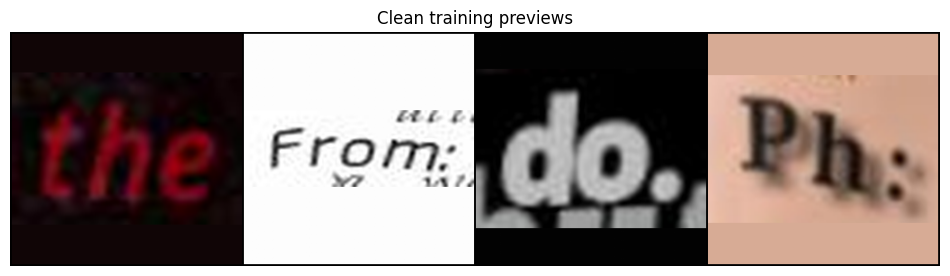

Training uses deterministic paired degradations on train crops for stable pix2pix supervision.
{'eval_engines': ['trocr', 'easyocr', 'tesseract', 'ocrspace']}


Epoch 1/28:   0%|          | 0/1210 [00:00<?, ?it/s]

Saved latest checkpoint: /kaggle/working/ocr_gan_checkpoints/gan_latest.pt
Updated best checkpoint: /kaggle/working/ocr_gan_checkpoints/gan_best.pt


Epoch 2/28:   0%|          | 0/1210 [00:00<?, ?it/s]

Saved latest checkpoint: /kaggle/working/ocr_gan_checkpoints/gan_latest.pt
Updated best checkpoint: /kaggle/working/ocr_gan_checkpoints/gan_best.pt


...

Epoch 27/28:   0%|          | 0/1210 [00:00<?, ?it/s]

Saved latest checkpoint: /kaggle/working/ocr_gan_checkpoints/gan_latest.pt


Epoch 28/28:   0%|          | 0/1210 [00:00<?, ?it/s]

Saved latest checkpoint: /kaggle/working/ocr_gan_checkpoints/gan_latest.pt
Loaded best generator checkpoint from /kaggle/working/ocr_gan_checkpoints/gan_best.pt


,epoch,g,d,l1,text_focus,structure,val_l1,val_text_focus,ocr_proxy_score,ocr_proxy_accuracy,ocr_proxy_cer,ocr_proxy_baseline_accuracy,ocr_proxy_baseline_cer,lr_g,lr_d
0,1,15.710992,0.183702,0.192943,0.475153,0.046568,0.173266,0.414665,0.195532,0.044271,1.080568,0.101562,0.959254,0.000100,0.000100
1,2,15.894153,0.094041,0.183041,0.448042,0.030243,0.171607,0.406556,0.302288,0.036458,1.153339,0.101562,0.959254,0.000100,0.000100
2,3,15.077397,0.105112,0.180317,0.437406,0.028718,0.169277,0.395732,0.053585,0.046875,0.973647,0.101562,0.959254,0.000099,0.000099
3,4,14.582442,0.106365,0.178061,0.430549,0.027112,0.175414,0.402906,-0.038067,0.091146,0.909599,0.101562,0.959254,0.000098,0.000098
4,5,14.458153,0.095923,0.177335,0.428668,0.026015,0.170347,0.393660,0.013408,0.088542,0.948834,0.101562,0.959254,0.000096,0.000096
5,6,15.233156,0.074864,0.179633,0.434626,0.030503,0.164270,0.381266,0.305858,0.111979,1.191935,0.101562,0.959254,0.000093,0.000093
6,7,14.596267,0.088669,0.176579,0.425820,0.025480,0.170064,0.387733,-0.280692,0.161458,0.778693,0.101562,0.959254,0.000091,0.000091
7,8,14.649322,0.082722,0.177014,0.426058,0.025041,0.172449,0.394614,-0.260656,0.164062,0.779067,0.101562,0.959254,0.000088,0.000088
8,9,14.667008,0.075601,0.177088,0.425754,0.025506,0.182297,0.425897,-0.018894,0.085938,0.924345,0.101562,0.959254,0.000084,0.000084
9,10,14.877854,0.066903,0.175911,0.423721,0.024519,0.163377,0.374782,-0.143772,0.158854,0.849597,0.101562,0.959254,0.000080,0.000080


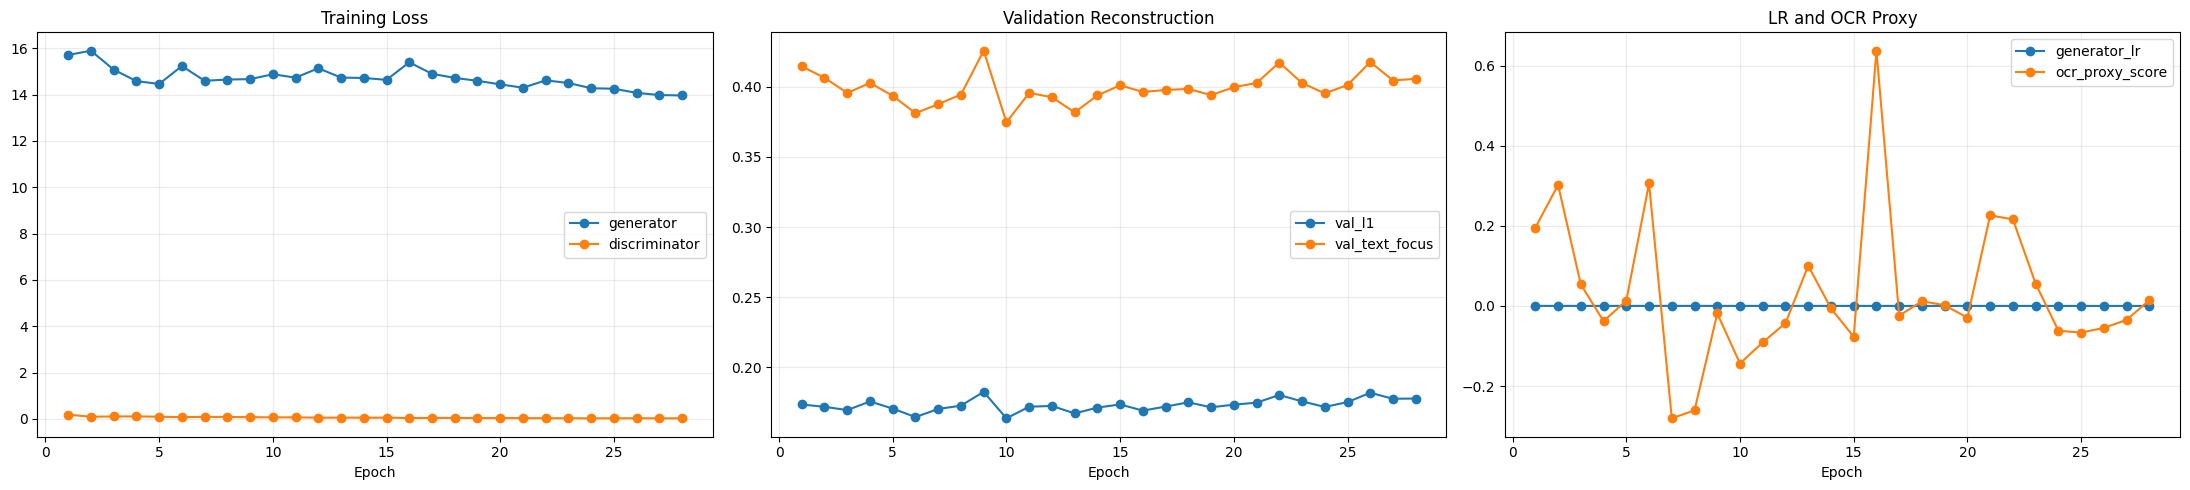

Evaluating OCR outputs:   0%|          | 0/320 [00:00<?, ?it/s]

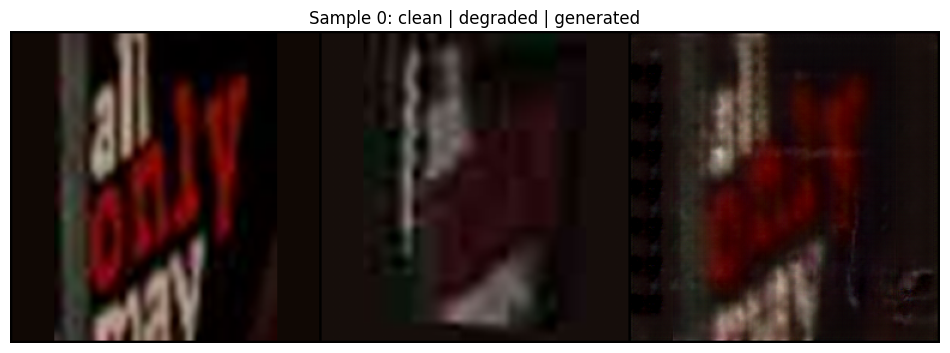

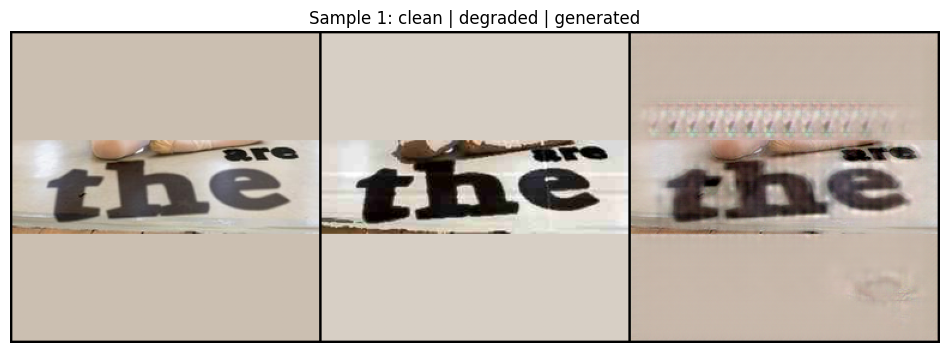

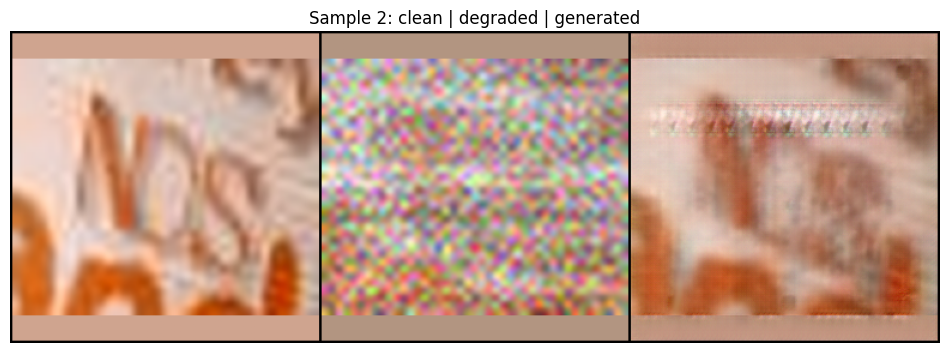

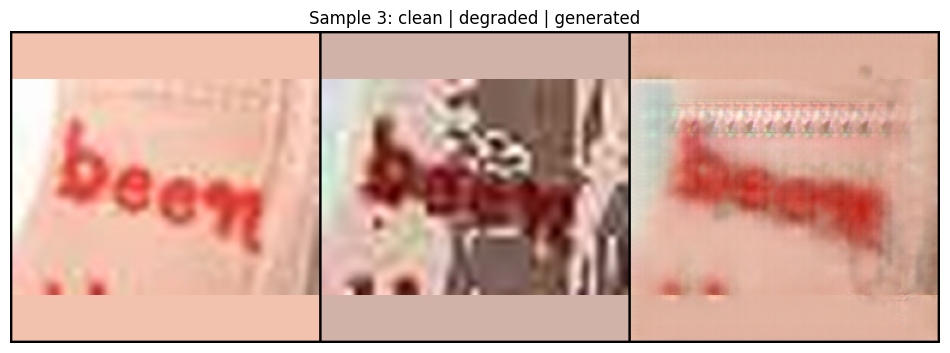

,index,engine,clean_text,clean_ocr,baseline_ocr,generated_ocr,image_path,source
0,0,trocr,only,TOTAL AMOUNT,PL,LIA,/kaggle/input/datasets/wassefy/synthtext/Synth...,synthtext_word
1,0,easyocr,only,d N A,4,,/kaggle/input/datasets/wassefy/synthtext/Synth...,synthtext_word
2,0,tesseract,only,a,i *,ee,/kaggle/input/datasets/wassefy/synthtext/Synth...,synthtext_word
3,0,ocrspace,only,,,,/kaggle/input/datasets/wassefy/synthtext/Synth...,synthtext_word
4,1,trocr,the,TAX:,TAX,.81,/kaggle/input/datasets/wassefy/synthtext/Synth...,synthtext_word


,index,engine,clean_text,clean_ocr,baseline_ocr,generated_ocr,image_path,source,has_reference,baseline_cer,...,baseline_exact_match,generated_cer,generated_wer,generated_exact_match,clean_ocr_cer,clean_ocr_wer,clean_ocr_exact_match,generated_cer_delta,generated_wer_delta,attack_success
0,0,trocr,only,TOTAL AMOUNT,PL,LIA,/kaggle/input/datasets/wassefy/synthtext/Synth...,synthtext_word,True,0.750000,...,False,1.0,1.0,False,2.5,2.0,False,0.250000,0.0,True
1,0,easyocr,only,d N A,4,,/kaggle/input/datasets/wassefy/synthtext/Synth...,synthtext_word,True,1.000000,...,False,1.0,1.0,False,1.0,3.0,False,0.000000,0.0,False
2,0,tesseract,only,a,i *,ee,/kaggle/input/datasets/wassefy/synthtext/Synth...,synthtext_word,True,1.000000,...,False,1.0,1.0,False,1.0,1.0,False,0.000000,-1.0,False
3,0,ocrspace,only,,,,/kaggle/input/datasets/wassefy/synthtext/Synth...,synthtext_word,True,1.000000,...,False,1.0,1.0,False,1.0,1.0,False,0.000000,0.0,False
4,1,trocr,the,TAX:,TAX,.81,/kaggle/input/datasets/wassefy/synthtext/Synth...,synthtext_word,True,0.666667,...,False,1.0,1.0,False,1.0,1.0,False,0.333333,0.0,True


,engine,samples,clean_accuracy,baseline_accuracy,generated_accuracy,attack_success_rate,clean_cer,baseline_cer,generated_cer,clean_wer,...,generated_wer,generated_cer_delta,generated_wer_delta,clean_accuracy_pct,baseline_accuracy_pct,generated_accuracy_pct,attack_success_rate_pct,generated_vs_baseline_accuracy_delta_pct,generated_vs_baseline_cer_delta,generated_vs_baseline_wer_delta
0,easyocr,320,0.306250,0.096875,0.081250,0.518750,0.678491,0.859748,1.733798,1.168750,...,1.60625,0.874049,0.434375,30.6250,9.6875,8.1250,51.8750,-1.5625,0.874049,0.434375
1,tesseract,320,0.187500,0.056250,0.065625,0.475000,0.653658,1.055501,1.383529,0.981250,...,1.90000,0.328029,0.453125,18.7500,5.6250,6.5625,47.5000,0.9375,0.328029,0.453125
2,ocrspace,320,0.109375,0.034375,0.056250,0.034375,0.887748,0.952713,0.932092,0.915625,...,0.96250,-0.020621,-0.012500,10.9375,3.4375,5.6250,3.4375,2.1875,-0.020621,-0.012500
3,trocr,320,0.406250,0.184375,0.103125,0.309375,0.592057,0.870731,0.839156,0.768750,...,0.92500,-0.031575,-0.025000,40.6250,18.4375,10.3125,30.9375,-8.1250,-0.031575,-0.025000


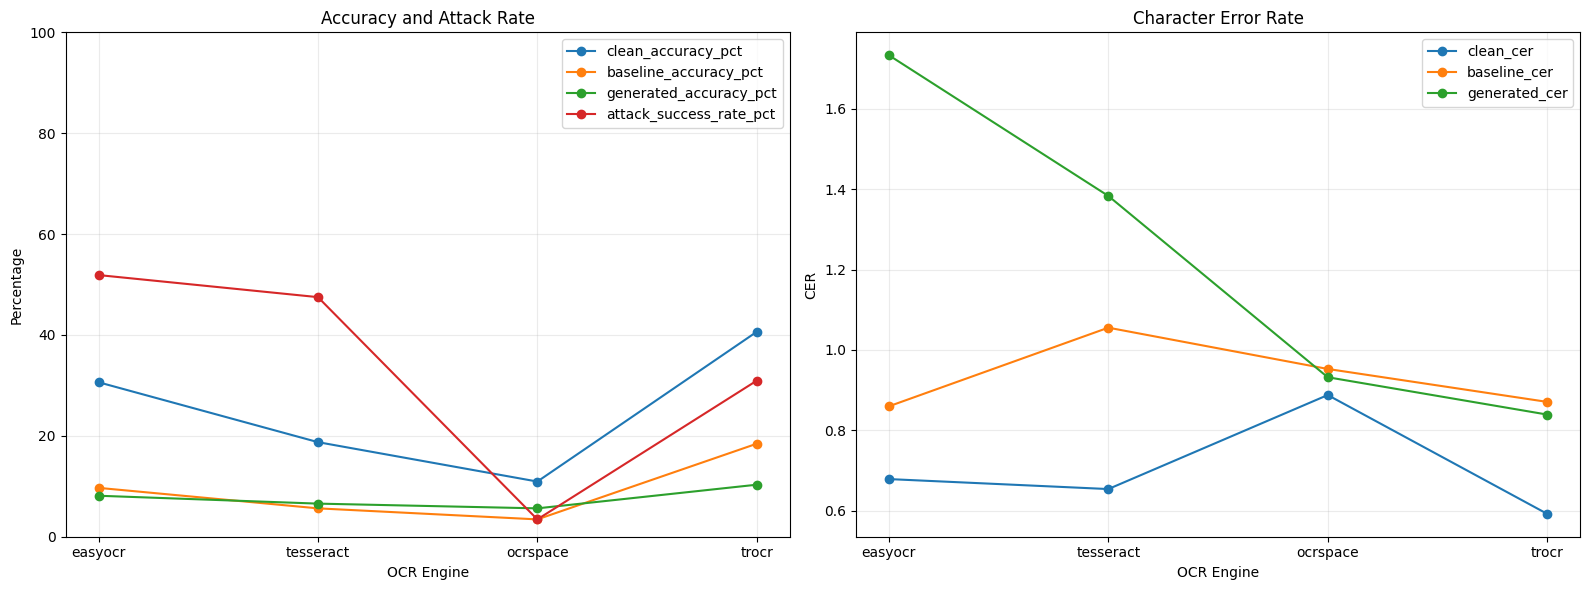

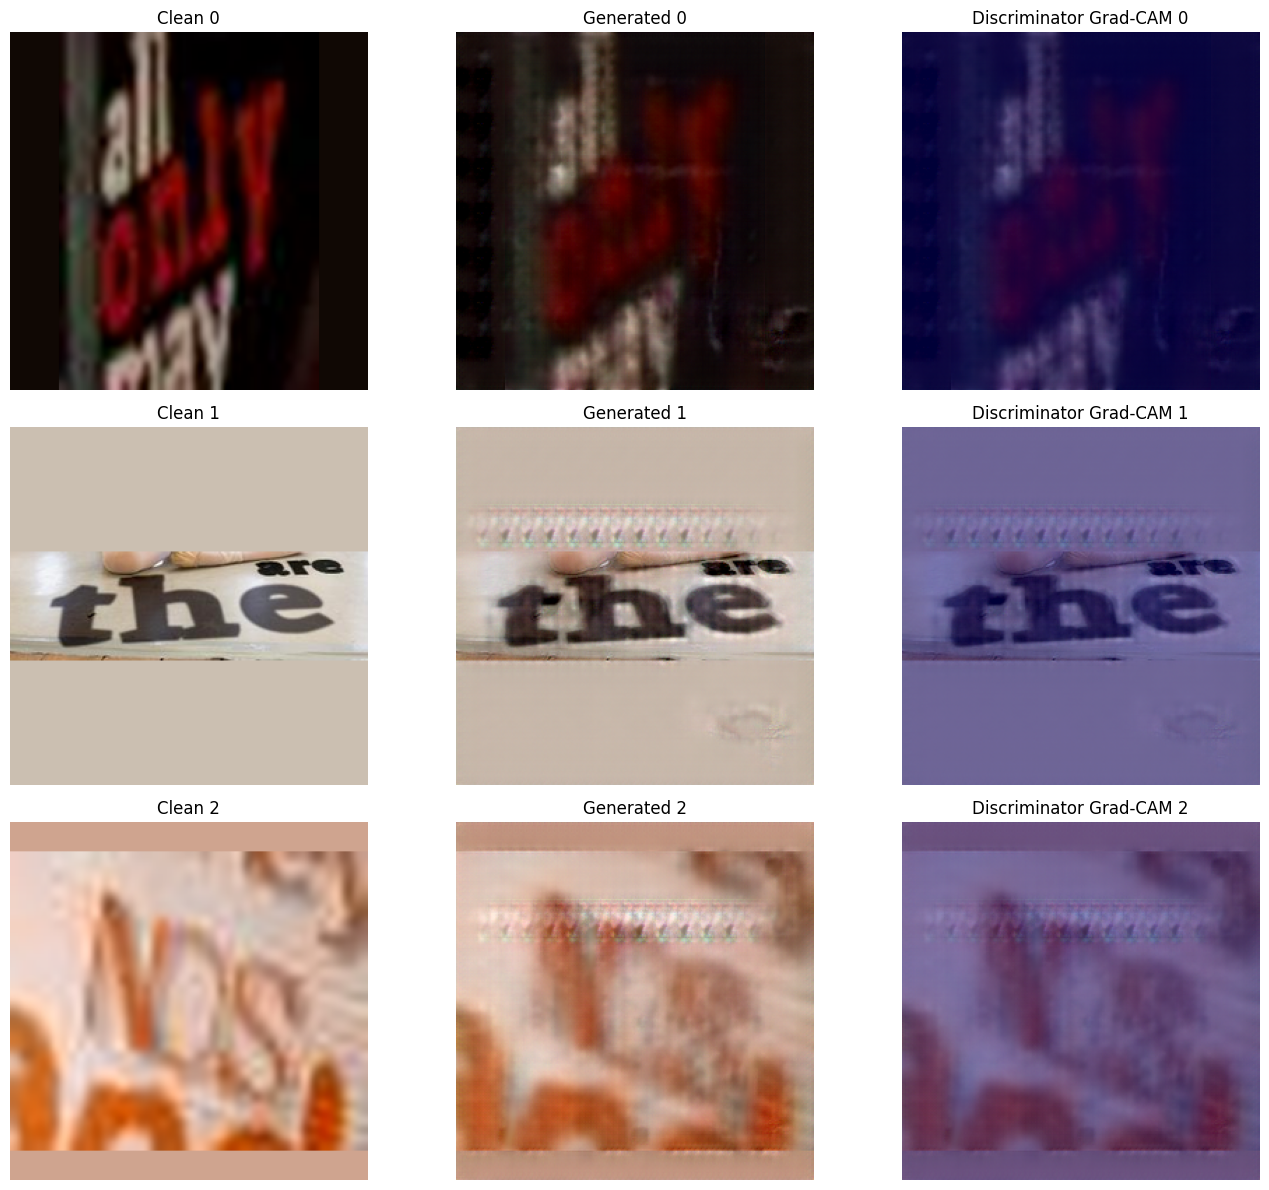

Saved OCR results to /kaggle/working/ocr_gan_outputs/ocr_gan_results.csv
Saved OCR summary to /kaggle/working/ocr_gan_outputs/ocr_gan_summary.csv
Training and evaluation helpers are ready.


In [9]:
def show_image_grid(tensor_batch: torch.Tensor, title: str = "Samples", nrow: int = 4) -> None:
    grid = make_grid(normalize_for_display(tensor_batch), nrow=nrow)
    plt.figure(figsize=(12, 8))
    plt.title(title)
    plt.axis("off")
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.show()


def plot_ocr_summary(summary_dataframe: pd.DataFrame) -> None:
    if summary_dataframe.empty:
        return

    _, axes = plt.subplots(1, 2, figsize=(16, 6))

    accuracy_columns = [
        "clean_accuracy_pct",
        "baseline_accuracy_pct",
        "generated_accuracy_pct",
        "attack_success_rate_pct",
    ]
    for metric_name in accuracy_columns:
        axes[0].plot(summary_dataframe["engine"], summary_dataframe[metric_name], marker="o", label=metric_name)
    axes[0].set_title("Accuracy and Attack Rate")
    axes[0].set_ylabel("Percentage")
    axes[0].set_xlabel("OCR Engine")
    axes[0].set_ylim(0, 100)
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    error_columns = ["clean_cer", "baseline_cer", "generated_cer"]
    for metric_name in error_columns:
        axes[1].plot(summary_dataframe["engine"], summary_dataframe[metric_name], marker="o", label=metric_name)
    axes[1].set_title("Character Error Rate")
    axes[1].set_ylabel("CER")
    axes[1].set_xlabel("OCR Engine")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_training_history(history_dataframe: pd.DataFrame) -> None:
    if history_dataframe.empty:
        return

    _, axes = plt.subplots(1, 3, figsize=(22, 5))
    axes[0].plot(history_dataframe["epoch"], history_dataframe["g"], marker="o", label="generator")
    axes[0].plot(history_dataframe["epoch"], history_dataframe["d"], marker="o", label="discriminator")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    validation_columns = [column for column in ["val_l1", "val_text_focus"] if column in history_dataframe.columns]
    for column_name in validation_columns:
        axes[1].plot(history_dataframe["epoch"], history_dataframe[column_name], marker="o", label=column_name)
    axes[1].set_title("Validation Reconstruction")
    axes[1].set_xlabel("Epoch")
    axes[1].grid(alpha=0.25)
    if validation_columns:
        axes[1].legend()

    if "lr_g" in history_dataframe.columns:
        axes[2].plot(history_dataframe["epoch"], history_dataframe["lr_g"], marker="o", label="generator_lr")
    if "ocr_proxy_score" in history_dataframe.columns:
        axes[2].plot(history_dataframe["epoch"], history_dataframe["ocr_proxy_score"], marker="o", label="ocr_proxy_score")
    axes[2].set_title("LR and OCR Proxy")
    axes[2].set_xlabel("Epoch")
    axes[2].grid(alpha=0.25)
    if any(column in history_dataframe.columns for column in ["lr_g", "ocr_proxy_score"]):
        axes[2].legend()

    plt.tight_layout()
    plt.show()


def build_train_eval_split(dataframe: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if dataframe.empty:
        return dataframe.copy(), dataframe.copy()

    working_dataframe = dataframe.copy()
    if "text" in working_dataframe.columns:
        labeled_mask = working_dataframe["text"].astype(str).str.strip().ne("")
        working_dataframe = working_dataframe[labeled_mask].reset_index(drop=True)
    if working_dataframe.empty:
        return dataframe.copy(), dataframe.head(0).copy()

    shuffled = working_dataframe.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)
    if len(shuffled) < 16:
        return shuffled.copy(), shuffled.head(min(len(shuffled), config.max_eval_samples)).copy()

    eval_count = int(round(len(shuffled) * config.eval_split))
    eval_count = max(16, eval_count)
    eval_count = min(eval_count, config.max_eval_samples, max(len(shuffled) - 1, 1))
    eval_dataframe = shuffled.iloc[:eval_count].reset_index(drop=True)
    train_dataframe = shuffled.iloc[eval_count:].reset_index(drop=True)
    if train_dataframe.empty:
        train_dataframe = shuffled.copy()
    return train_dataframe, eval_dataframe


def to_serializable_config(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {key: to_serializable_config(item) for key, item in value.items()}
    if isinstance(value, list):
        return [to_serializable_config(item) for item in value]
    if isinstance(value, tuple):
        return [to_serializable_config(item) for item in value]
    return value


def build_checkpoint_payload(epoch_index: int, history_row: Dict[str, float]) -> Dict[str, object]:
    return {
        "generator": G.state_dict(),
        "discriminator": D.state_dict(),
        "optimizer_g": optimizer_g.state_dict(),
        "optimizer_d": optimizer_d.state_dict(),
        "scheduler_g": scheduler_g.state_dict(),
        "scheduler_d": scheduler_d.state_dict(),
        "epoch": epoch_index + 1,
        "config": to_serializable_config(config.__dict__),
        "history_row": history_row,
    }


def load_checkpoint_file(checkpoint_path: Path) -> Dict[str, object]:
    import pickle

    try:
        return torch.load(checkpoint_path, map_location=DEVICE)
    except pickle.UnpicklingError:
        return torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)


def remove_old_epoch_checkpoints(checkpoints_root: Path) -> int:
    removed_count = 0
    for checkpoint_path in checkpoints_root.glob("gan_epoch_*.pt"):
        try:
            checkpoint_path.unlink()
            removed_count += 1
        except OSError:
            continue
    return removed_count


def compute_ocr_proxy_metrics(sample_limit: int = 96) -> Dict[str, float]:
    if eval_dataset is None or len(eval_dataset) == 0:
        return {"ocr_proxy_score": float("nan"), "ocr_proxy_accuracy": float("nan"), "ocr_proxy_cer": float("nan")}

    proxy_engines = [engine_name for engine_name in ["trocr", "easyocr", "tesseract"] if engine_name in EVAL_ENGINES]
    if not proxy_engines:
        return {"ocr_proxy_score": float("nan"), "ocr_proxy_accuracy": float("nan"), "ocr_proxy_cer": float("nan")}

    G.eval()
    attack_scores = []
    baseline_exact_matches = []
    generated_exact_matches = []
    baseline_cer_values = []
    generated_cer_values = []
    effective_limit = min(len(eval_dataset), sample_limit)

    for index in range(effective_limit):
        sample = eval_dataset[index]
        clean_text = str(sample.get("text", "")).strip()
        if not clean_text:
            continue

        clean_image = sample["clean"].unsqueeze(0).to(DEVICE)
        generated_image = G(clean_image)[0].cpu()
        generated_pil = tensor_to_pil(generated_image)
        baseline_pil = tensor_to_pil(sample["degraded"])

        for engine_name in proxy_engines:
            baseline_text = run_ocr_engine(engine_name, baseline_pil)
            generated_text = run_ocr_engine(engine_name, generated_pil)

            baseline_exact = float(exact_match(baseline_text, clean_text))
            generated_exact = float(exact_match(generated_text, clean_text))
            baseline_cer = float(character_error_rate(baseline_text, clean_text))
            generated_cer = float(character_error_rate(generated_text, clean_text))
            baseline_wer = float(word_error_rate(baseline_text, clean_text))
            generated_wer = float(word_error_rate(generated_text, clean_text))

            attack_score = (
                (generated_cer - baseline_cer)
                + 0.35 * (generated_wer - baseline_wer)
                + 0.5 * (baseline_exact - generated_exact)
            )
            attack_scores.append(float(attack_score))
            baseline_exact_matches.append(baseline_exact)
            generated_exact_matches.append(generated_exact)
            baseline_cer_values.append(baseline_cer)
            generated_cer_values.append(generated_cer)

    if not attack_scores:
        return {"ocr_proxy_score": float("nan"), "ocr_proxy_accuracy": float("nan"), "ocr_proxy_cer": float("nan")}

    return {
        "ocr_proxy_score": float(np.mean(attack_scores)),
        "ocr_proxy_accuracy": float(np.mean(generated_exact_matches)),
        "ocr_proxy_cer": float(np.mean(generated_cer_values)),
        "ocr_proxy_baseline_accuracy": float(np.mean(baseline_exact_matches)),
        "ocr_proxy_baseline_cer": float(np.mean(baseline_cer_values)),
    }


train_dataframe, eval_dataframe = build_train_eval_split(dataset_dataframe)
print({
    "train_samples": int(len(train_dataframe)),
    "eval_samples": int(len(eval_dataframe)),
})

if len(train_dataframe) > 0:
    preview_dataset = PairedDocumentDataset(
        train_dataframe.head(min(8, len(train_dataframe))),
        image_size=config.image_size,
        training=False,
    )
    preview_batch = [preview_dataset[index]["clean"] for index in range(min(4, len(preview_dataset)))]
    if preview_batch:
        show_image_grid(torch.stack(preview_batch), title="Clean training previews")


TRAIN_DEGRADATION_SEED = RANDOM_SEED + 1_000
EVAL_DEGRADATION_SEED = RANDOM_SEED + 2_000

train_dataset = PairedDocumentDataset(
    train_dataframe,
    image_size=config.image_size,
    training=True,
    deterministic_degradation=True,
    base_seed=TRAIN_DEGRADATION_SEED,
) if len(train_dataframe) > 0 else None

eval_dataset = PairedDocumentDataset(
    eval_dataframe,
    image_size=config.image_size,
    training=True,
    deterministic_degradation=True,
    base_seed=EVAL_DEGRADATION_SEED,
) if len(eval_dataframe) > 0 else None

train_loader = None
if train_dataset is not None and len(train_dataset) > 0:
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=True,
        persistent_workers=bool(config.num_workers > 0),
    )
    print("Training uses deterministic paired degradations on train crops for stable pix2pix supervision.")


optimizer_g = torch.optim.Adam(G.parameters(), lr=config.learning_rate, betas=(config.beta1, 0.999))
optimizer_d = torch.optim.Adam(D.parameters(), lr=config.learning_rate, betas=(config.beta1, 0.999))
scheduler_g = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_g,
    T_max=max(config.epochs, 1),
    eta_min=config.learning_rate * config.min_learning_rate_ratio,
)
scheduler_d = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_d,
    T_max=max(config.epochs, 1),
    eta_min=config.learning_rate * config.min_learning_rate_ratio,
)
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())


def is_ocr_engine_available(engine_name: str) -> bool:
    if engine_name == "trocr":
        return trocr_ocr.model is not None
    if engine_name == "easyocr":
        return easy_ocr.reader is not None
    if engine_name == "tesseract":
        return pytesseract is not None
    if engine_name == "ocrspace":
        return bool(config.ocrspace_api_key)
    return False


EVAL_ENGINES = [engine_name for engine_name in ["trocr", "easyocr", "tesseract", "ocrspace"] if is_ocr_engine_available(engine_name)]
ATTACK_CER_MARGIN = 0.02
ATTACK_WER_MARGIN = 0.02
print({"eval_engines": EVAL_ENGINES})


def total_variation_loss(image: torch.Tensor) -> torch.Tensor:
    loss_horizontal = torch.mean(torch.abs(image[:, :, :, 1:] - image[:, :, :, :-1]))
    loss_vertical = torch.mean(torch.abs(image[:, :, 1:, :] - image[:, :, :-1, :]))
    return loss_horizontal + loss_vertical


@torch.no_grad()
def evaluate_generator_reconstruction(sample_limit: int = 128) -> Dict[str, float]:
    if eval_dataset is None or len(eval_dataset) == 0:
        return {"val_l1": float("nan"), "val_text_focus": float("nan")}

    G.eval()
    total_l1 = 0.0
    total_text_focus = 0.0
    evaluated = 0
    effective_limit = min(len(eval_dataset), sample_limit)

    for index in range(effective_limit):
        sample = eval_dataset[index]
        clean_image = sample["clean"].unsqueeze(0).to(DEVICE)
        target_image = sample["degraded"].unsqueeze(0).to(DEVICE)
        fake_image = G(clean_image)
        total_l1 += float(reconstruction_criterion(fake_image, target_image).detach().cpu())
        total_text_focus += float(text_focus_loss(fake_image, target_image, clean_image).detach().cpu())
        evaluated += 1

    if evaluated == 0:
        return {"val_l1": float("nan"), "val_text_focus": float("nan")}
    return {
        "val_l1": total_l1 / evaluated,
        "val_text_focus": total_text_focus / evaluated,
    }


def train_one_epoch(epoch_index: int) -> Dict[str, float]:
    if train_loader is None:
        raise RuntimeError("No training data found. Attach a Kaggle dataset and rerun the notebook.")

    G.train()
    D.train()
    running_losses = {
        "g": 0.0,
        "d": 0.0,
        "l1": 0.0,
        "text_focus": 0.0,
        "structure": 0.0,
    }
    progress = tqdm(train_loader, desc=f"Epoch {epoch_index + 1}/{config.epochs}")

    for step_index, batch in enumerate(progress, start=1):
        clean_image = batch["clean"].to(DEVICE, non_blocking=True)
        target_image = batch["degraded"].to(DEVICE, non_blocking=True)

        optimizer_d.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            fake_image_detached = G(clean_image).detach()
            real_prediction = D(clean_image, target_image)
            fake_prediction = D(clean_image, fake_image_detached)
            loss_d = discriminator_loss(real_prediction, fake_prediction)
        scaler.scale(loss_d).backward()
        scaler.step(optimizer_d)

        optimizer_g.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            fake_image = G(clean_image)
            fake_prediction_for_g = D(clean_image, fake_image)
            identity_image = G(target_image)
            losses = generator_loss(fake_prediction_for_g, fake_image, target_image, identity_image, clean_image)
            residual_tv_loss = total_variation_loss(fake_image - clean_image)
            total_generator_loss = losses["total"] + config.lambda_tv * residual_tv_loss
        scaler.scale(total_generator_loss).backward()
        scaler.step(optimizer_g)
        scaler.update()

        running_losses["g"] += float(total_generator_loss.detach().cpu())
        running_losses["d"] += float(loss_d.detach().cpu())
        running_losses["l1"] += float(losses["l1"].detach().cpu())
        running_losses["text_focus"] += float(losses["text_focus"].detach().cpu())
        running_losses["structure"] += float(losses["structure"].detach().cpu())
        progress.set_postfix({
            "g_loss": running_losses["g"] / step_index,
            "d_loss": running_losses["d"] / step_index,
            "text_focus": running_losses["text_focus"] / step_index,
        })

    return {key: value / max(len(train_loader), 1) for key, value in running_losses.items()}


history_rows = []
best_validation_score = float("inf")
best_validation_checkpoint_score = float("inf")
best_ocr_proxy_score = float("-inf")
checkpoint_attack_warmup_epochs = 3
best_checkpoint_path = config.checkpoints_root / "gan_best.pt"
latest_checkpoint_path = config.checkpoints_root / "gan_latest.pt"

if train_loader is not None:
    removed_count = remove_old_epoch_checkpoints(config.checkpoints_root)
    if removed_count:
        print(f"Removed {removed_count} old per-epoch checkpoints from {config.checkpoints_root}")

    for epoch_index in range(config.epochs):
        epoch_losses = train_one_epoch(epoch_index)
        validation_metrics = evaluate_generator_reconstruction(sample_limit=min(128, len(eval_dataset) if eval_dataset is not None else 0))

        should_run_ocr_proxy = (
            len(EVAL_ENGINES) > 0
            and config.ocr_proxy_eval_frequency > 0
            and ((epoch_index + 1) % config.ocr_proxy_eval_frequency == 0 or epoch_index + 1 == config.epochs)
        )
        ocr_proxy_metrics = (
            compute_ocr_proxy_metrics(sample_limit=config.ocr_proxy_eval_samples)
            if should_run_ocr_proxy
            else {"ocr_proxy_score": float("nan"), "ocr_proxy_accuracy": float("nan"), "ocr_proxy_cer": float("nan")}
        )

        history_row = {
            "epoch": epoch_index + 1,
            **epoch_losses,
            **validation_metrics,
            **ocr_proxy_metrics,
            "lr_g": float(optimizer_g.param_groups[0]["lr"]),
            "lr_d": float(optimizer_d.param_groups[0]["lr"]),
        }
        history_rows.append(history_row)

        checkpoint_payload = build_checkpoint_payload(epoch_index, history_row)
        torch.save(checkpoint_payload, latest_checkpoint_path)
        print(f"Saved latest checkpoint: {latest_checkpoint_path}")

        validation_score = float(validation_metrics.get("val_text_focus", float("inf")) + validation_metrics.get("val_l1", float("inf")))
        ocr_proxy_score = float(ocr_proxy_metrics.get("ocr_proxy_score", float("nan")))
        if math.isfinite(validation_score):
            best_validation_score = min(best_validation_score, validation_score)

        choose_by_ocr = (
            math.isfinite(ocr_proxy_score)
            and epoch_index + 1 >= checkpoint_attack_warmup_epochs
            and ocr_proxy_score > best_ocr_proxy_score
        )
        choose_by_validation = (
            not choose_by_ocr
            and not math.isfinite(best_ocr_proxy_score)
            and math.isfinite(validation_score)
            and validation_score < best_validation_checkpoint_score
        )

        if choose_by_ocr or choose_by_validation:
            if choose_by_ocr:
                best_ocr_proxy_score = ocr_proxy_score
            if choose_by_validation:
                best_validation_checkpoint_score = validation_score
            torch.save(checkpoint_payload, best_checkpoint_path)
            print(f"Updated best checkpoint: {best_checkpoint_path}")

        scheduler_g.step()
        scheduler_d.step()

if best_checkpoint_path.exists():
    best_checkpoint = load_checkpoint_file(best_checkpoint_path)
    G.load_state_dict(best_checkpoint["generator"])
    print(f"Loaded best generator checkpoint from {best_checkpoint_path}")

history_dataframe = pd.DataFrame(history_rows)
display(history_dataframe)
plot_training_history(history_dataframe)


@torch.no_grad()
def generate_sample_outputs(sample_count: Optional[int] = None) -> pd.DataFrame:
    if eval_dataset is None or len(eval_dataset) == 0:
        return pd.DataFrame()
    if not EVAL_ENGINES:
        print("No OCR engines are available for evaluation.")
        return pd.DataFrame()

    G.eval()
    records = []
    effective_sample_count = min(len(eval_dataset), sample_count or config.max_eval_samples or len(eval_dataset))
    for index in tqdm(range(effective_sample_count), desc="Evaluating OCR outputs"):
        sample = eval_dataset[index]
        clean_image = sample["clean"].unsqueeze(0).to(DEVICE)
        predicted_image = G(clean_image)[0].cpu()
        predicted_pil = tensor_to_pil(predicted_image)
        clean_pil = tensor_to_pil(sample["clean"])
        degraded_pil = tensor_to_pil(sample["degraded"])
        clean_text = sample.get("text", "")
        for engine_name in EVAL_ENGINES:
            predicted_text = run_ocr_engine(engine_name, predicted_pil)
            baseline_text = run_ocr_engine(engine_name, degraded_pil)
            clean_ocr_text = run_ocr_engine(engine_name, clean_pil)
            records.append({
                "index": index,
                "engine": engine_name,
                "clean_text": clean_text,
                "clean_ocr": clean_ocr_text,
                "baseline_ocr": baseline_text,
                "generated_ocr": predicted_text,
                "image_path": sample["path"],
                "source": sample.get("source", "unknown"),
            })
        if index < 4:
            comparison_grid = torch.stack([sample["clean"], sample["degraded"], predicted_image])
            show_image_grid(comparison_grid, title=f"Sample {index}: clean | degraded | generated", nrow=3)
    return pd.DataFrame(records)


def evaluate_ocr_outputs(result_dataframe: pd.DataFrame) -> pd.DataFrame:
    if result_dataframe.empty:
        return result_dataframe

    evaluation_rows = []
    for _, row in result_dataframe.iterrows():
        clean_text = row["clean_text"]
        has_reference = bool(normalize_text(clean_text))
        if has_reference:
            clean_exact = exact_match(row["clean_ocr"], clean_text)
            baseline_exact = exact_match(row["baseline_ocr"], clean_text)
            generated_exact = exact_match(row["generated_ocr"], clean_text)
            clean_cer = character_error_rate(row["clean_ocr"], clean_text)
            baseline_cer = character_error_rate(row["baseline_ocr"], clean_text)
            generated_cer = character_error_rate(row["generated_ocr"], clean_text)
            clean_wer = word_error_rate(row["clean_ocr"], clean_text)
            baseline_wer = word_error_rate(row["baseline_ocr"], clean_text)
            generated_wer = word_error_rate(row["generated_ocr"], clean_text)
            attack_success = bool(
                (generated_cer > baseline_cer + ATTACK_CER_MARGIN)
                or (generated_wer > baseline_wer + ATTACK_WER_MARGIN)
                or (baseline_exact and not generated_exact)
            )
        else:
            clean_exact = False
            baseline_exact = False
            generated_exact = False
            clean_cer = np.nan
            baseline_cer = np.nan
            generated_cer = np.nan
            clean_wer = np.nan
            baseline_wer = np.nan
            generated_wer = np.nan
            attack_success = False

        evaluation_rows.append({
            **row.to_dict(),
            "has_reference": has_reference,
            "baseline_cer": baseline_cer,
            "baseline_wer": baseline_wer,
            "baseline_exact_match": baseline_exact,
            "generated_cer": generated_cer,
            "generated_wer": generated_wer,
            "generated_exact_match": generated_exact,
            "clean_ocr_cer": clean_cer,
            "clean_ocr_wer": clean_wer,
            "clean_ocr_exact_match": clean_exact,
            "generated_cer_delta": generated_cer - baseline_cer if has_reference else np.nan,
            "generated_wer_delta": generated_wer - baseline_wer if has_reference else np.nan,
            "attack_success": attack_success,
        })
    return pd.DataFrame(evaluation_rows)


def summarize_ocr_metrics(evaluation_dataframe: pd.DataFrame) -> pd.DataFrame:
    if evaluation_dataframe.empty:
        return evaluation_dataframe

    labeled_dataframe = evaluation_dataframe[evaluation_dataframe["has_reference"]].copy()
    if labeled_dataframe.empty:
        return pd.DataFrame()

    summary_dataframe = (
        labeled_dataframe.groupby("engine", dropna=False)
        .agg(
            samples=("index", "count"),
            clean_accuracy=("clean_ocr_exact_match", "mean"),
            baseline_accuracy=("baseline_exact_match", "mean"),
            generated_accuracy=("generated_exact_match", "mean"),
            attack_success_rate=("attack_success", "mean"),
            clean_cer=("clean_ocr_cer", "mean"),
            baseline_cer=("baseline_cer", "mean"),
            generated_cer=("generated_cer", "mean"),
            clean_wer=("clean_ocr_wer", "mean"),
            baseline_wer=("baseline_wer", "mean"),
            generated_wer=("generated_wer", "mean"),
            generated_cer_delta=("generated_cer_delta", "mean"),
            generated_wer_delta=("generated_wer_delta", "mean"),
        )
        .reset_index()
    )

    for column in [
        "clean_accuracy",
        "baseline_accuracy",
        "generated_accuracy",
        "attack_success_rate",
        "clean_cer",
        "baseline_cer",
        "generated_cer",
        "clean_wer",
        "baseline_wer",
        "generated_wer",
        "generated_cer_delta",
        "generated_wer_delta",
    ]:
        summary_dataframe[column] = summary_dataframe[column].astype(float)

    summary_dataframe["clean_accuracy_pct"] = summary_dataframe["clean_accuracy"] * 100.0
    summary_dataframe["baseline_accuracy_pct"] = summary_dataframe["baseline_accuracy"] * 100.0
    summary_dataframe["generated_accuracy_pct"] = summary_dataframe["generated_accuracy"] * 100.0
    summary_dataframe["attack_success_rate_pct"] = summary_dataframe["attack_success_rate"] * 100.0
    summary_dataframe["generated_vs_baseline_accuracy_delta_pct"] = (
        summary_dataframe["generated_accuracy_pct"] - summary_dataframe["baseline_accuracy_pct"]
    )
    summary_dataframe["generated_vs_baseline_cer_delta"] = (
        summary_dataframe["generated_cer"] - summary_dataframe["baseline_cer"]
    )
    summary_dataframe["generated_vs_baseline_wer_delta"] = (
        summary_dataframe["generated_wer"] - summary_dataframe["baseline_wer"]
    )

    return summary_dataframe.sort_values("generated_cer_delta", ascending=False).reset_index(drop=True)


def print_ocr_sanity_checks(summary_dataframe: pd.DataFrame) -> None:
    if summary_dataframe.empty:
        return

    low_clean_accuracy = bool((summary_dataframe["clean_accuracy_pct"] <= 10.0).all())
    high_clean_cer = bool((summary_dataframe["clean_cer"] >= 0.4).all())
    if low_clean_accuracy and high_clean_cer:
        print(
            "Sanity check: clean OCR is still weak. Reduce max_text_length, inspect the train/eval crops, "
            "or switch the dataset to even tighter word-level regions."
        )


def compute_discriminator_gradcam(clean_tensor: torch.Tensor, target_tensor: torch.Tensor) -> Optional[np.ndarray]:
    target_module = None
    for module in reversed(list(D.model)):
        if isinstance(module, nn.Conv2d):
            target_module = module
            break

    if target_module is None:
        return None

    activations = []
    gradients = []

    def forward_hook(*hook_args):
        activations.append(hook_args[2])

    def backward_hook(*hook_args):
        gradients.append(hook_args[2][0])

    forward_handle = target_module.register_forward_hook(forward_hook)
    backward_handle = target_module.register_full_backward_hook(backward_hook)

    try:
        D.eval()
        D.zero_grad(set_to_none=True)
        prediction = D(clean_tensor, target_tensor)
        score = prediction.mean()
        score.backward()

        if not activations or not gradients:
            return None

        activation_map = activations[0]
        gradient_map = gradients[0]
        weights = gradient_map.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * activation_map).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=clean_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam[0, 0].detach().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam
    finally:
        forward_handle.remove()
        backward_handle.remove()
        D.zero_grad(set_to_none=True)


def visualize_discriminator_gradcam(sample_count: int = 3) -> None:
    if eval_dataset is None or len(eval_dataset) == 0 or sample_count <= 0:
        print("No data available for Grad-CAM visualization.")
        return

    _, axes = plt.subplots(sample_count, 3, figsize=(14, 4 * sample_count))
    if sample_count == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index in range(sample_count):
        sample = eval_dataset[row_index]
        clean_tensor = sample["clean"].unsqueeze(0).to(DEVICE)
        generated_tensor = G(clean_tensor).detach()
        cam = compute_discriminator_gradcam(clean_tensor, generated_tensor)

        clean_image = tensor_to_pil(sample["clean"])
        generated_image = tensor_to_pil(generated_tensor[0].cpu())

        axes[row_index, 0].imshow(clean_image)
        axes[row_index, 0].set_title(f"Clean {row_index}")
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(generated_image)
        axes[row_index, 1].set_title(f"Generated {row_index}")
        axes[row_index, 1].axis("off")

        axes[row_index, 2].imshow(generated_image)
        if cam is not None:
            axes[row_index, 2].imshow(cam, cmap="jet", alpha=0.45)
        axes[row_index, 2].set_title(f"Discriminator Grad-CAM {row_index}")
        axes[row_index, 2].axis("off")

    plt.tight_layout()
    plt.show()


sample_results = generate_sample_outputs()
display(sample_results.head())

sample_evaluation = evaluate_ocr_outputs(sample_results)
display(sample_evaluation.head())

ocr_summary = summarize_ocr_metrics(sample_evaluation)
if not ocr_summary.empty:
    display(ocr_summary)
    print_ocr_sanity_checks(ocr_summary)
    plot_ocr_summary(ocr_summary)
else:
    print("OCR summary is empty. This usually means no labeled samples or no OCR outputs were produced.")

visualize_discriminator_gradcam(sample_count=min(config.gradcam_samples, len(eval_dataset) if eval_dataset is not None else 0))

results_csv_path = config.output_root / "ocr_gan_results.csv"
if not sample_evaluation.empty:
    sample_evaluation.to_csv(results_csv_path, index=False)
    print(f"Saved OCR results to {results_csv_path}")

summary_csv_path = config.output_root / "ocr_gan_summary.csv"
if not ocr_summary.empty:
    ocr_summary.to_csv(summary_csv_path, index=False)
    print(f"Saved OCR summary to {summary_csv_path}")

summary_path = config.output_root / "training_summary.json"
with open(summary_path, "w", encoding="utf-8") as summary_file:
    json.dump(
        {
            "history": history_rows,
            "num_samples": int(len(dataset_dataframe)),
            "train_samples": int(len(train_dataframe)),
            "evaluated_samples": int(0 if sample_results.empty else sample_results["index"].nunique()),
            "device": str(DEVICE),
            "eval_engines": EVAL_ENGINES,
            "attack_thresholds": {
                "cer_margin": ATTACK_CER_MARGIN,
                "wer_margin": ATTACK_WER_MARGIN,
            },
            "train_degradation_seed": TRAIN_DEGRADATION_SEED,
            "eval_degradation_seed": EVAL_DEGRADATION_SEED,
            "latest_checkpoint": str(latest_checkpoint_path) if latest_checkpoint_path.exists() else "",
            "best_checkpoint": str(best_checkpoint_path) if best_checkpoint_path.exists() else "",
            "best_validation_score": None if not math.isfinite(best_validation_score) else best_validation_score,
            "best_ocr_proxy_score": None if not math.isfinite(best_ocr_proxy_score) else best_ocr_proxy_score,
            "ocr_summary": [] if ocr_summary.empty else ocr_summary.to_dict(orient="records"),
        },
        summary_file,
        indent=2,
    )

print("Training and evaluation helpers are ready.")